In [1]:
import json
import pandas as pd
from IPython.display import Image, JSON, display
from run_main import run
from helper_funcs import get_worm_json, write_worm_json, delete_directory, delete_notebook_directory

In [2]:
notebookFolder = "notebooks"
notebookSubFolder = "example_W2D18L_evo"
origFolderName="notebooks/example_W2D18L"
outputFolderName= notebookFolder + '/' + notebookSubFolder
delete_notebook_directory(notebookFolder, notebookSubFolder)

True

Further optimizations can also be performed with the "W2DSR" model. The parameters used are those supplied in the command line arguments, or if not, in the 'Evolutionary Optimization Parameters' of the JSON file (if there is no JSON file defaults are used):

In [3]:
json_data = get_worm_json(origFolderName)
print('Evolutionary Optimization Parameters: ' + json.dumps(json_data['Evolutionary Optimization Parameters'], indent=2))

Evolutionary Optimization Parameters: {
  "CheckpointInterval": {
    "value": 5
  },
  "CrossoverMode": {
    "value": 0
  },
  "CrossoverProbability": {
    "value": 0.5
  },
  "Duration": {
    "value": 50.0
  },
  "ElitistFraction": {
    "value": 0.04
  },
  "MaxExpectedOffspring": {
    "value": 1.1
  },
  "MaxGenerations": {
    "value": 120
  },
  "MutationVariance": {
    "value": 0.1
  },
  "N_curvs": {
    "value": 23
  },
  "PopulationSize": {
    "value": 66
  },
  "ReEvaluationFlag": {
    "value": 1
  },
  "ReproductionMode": {
    "value": 1
  },
  "SearchConstraint": {
    "value": 1
  },
  "SelectionMode": {
    "value": 1
  },
  "StepSize": {
    "value": 0.01
  },
  "Transient": {
    "value": 10.0
  },
  "VectSize": {
    "value": 30
  },
  "VectSize_temo": {
    "value": -1
  },
  "agarfreq": {
    "value": 0.44
  },
  "avg_speed": {
    "value": 0.00022
  },
  "evo_type": {
    "value": "Evo18"
  },
  "fileprefix": {
    "value": ""
  },
  "osc_tbase": {
    "val

In [4]:
args = dict(
    modelFolder="Worm2D", #folder containing the compiled C++ binary code
    modelName="W2DSR",#rerun using the generic json loaded model
    outputFolderName=outputFolderName, #output folder
    inputFolderName=origFolderName, #input folder
    overwrite=True, #allow overwrite of output folder 
    randInitState=False, #use fixed initial conditions from JSON file
    doTestRun=True, #run a single simple simulation
)

Directory 'notebooks/example_W2D18L_evo' created successfully.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '10', '--max_generations', '5', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR']
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_evo/search.cpt with size 30
setting  population size to cpt population size: 66
Resuming search
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo/body.dat
Saved plot image to: notebooks/example_W2D18L_evo/Example

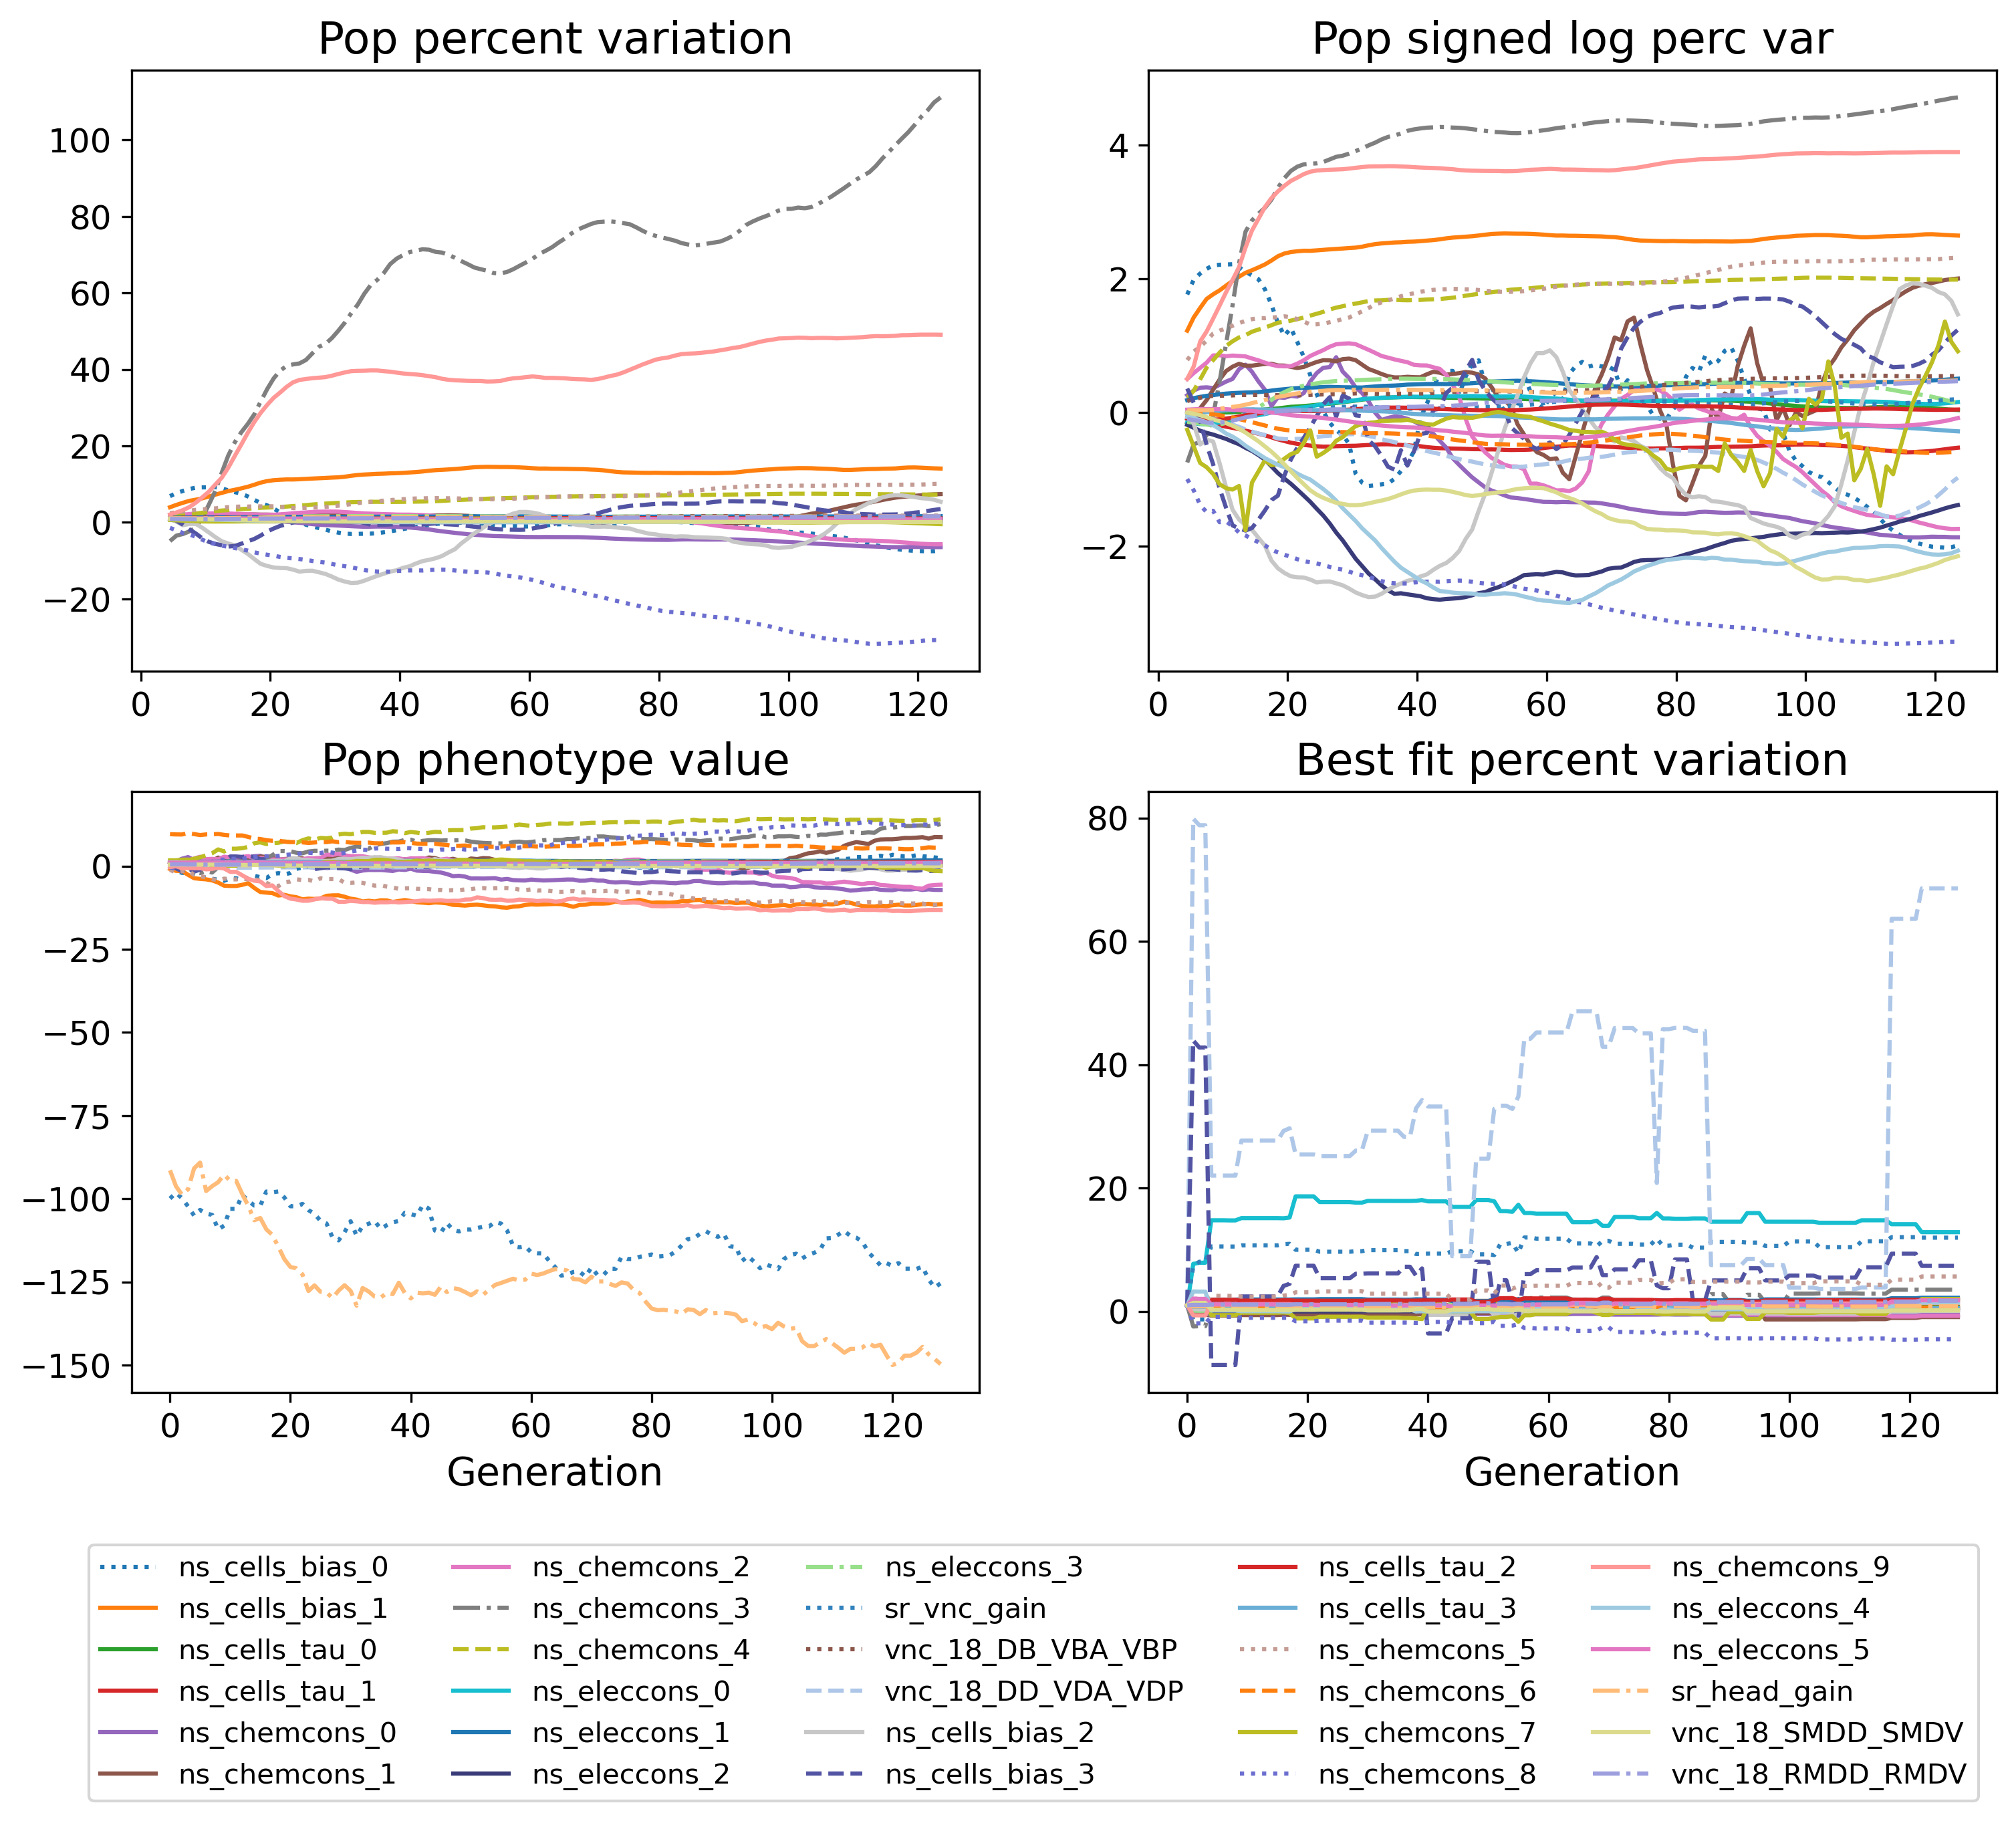

In [5]:
args['doEvol']=True #perform the optimization before running the simulation
args['evoAvLen']=10 #plot moving average of evolution history figures  
args['maxGens']=5 #run the optimization for ten more generations 
args['popSize']=10 #population size for optimization
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

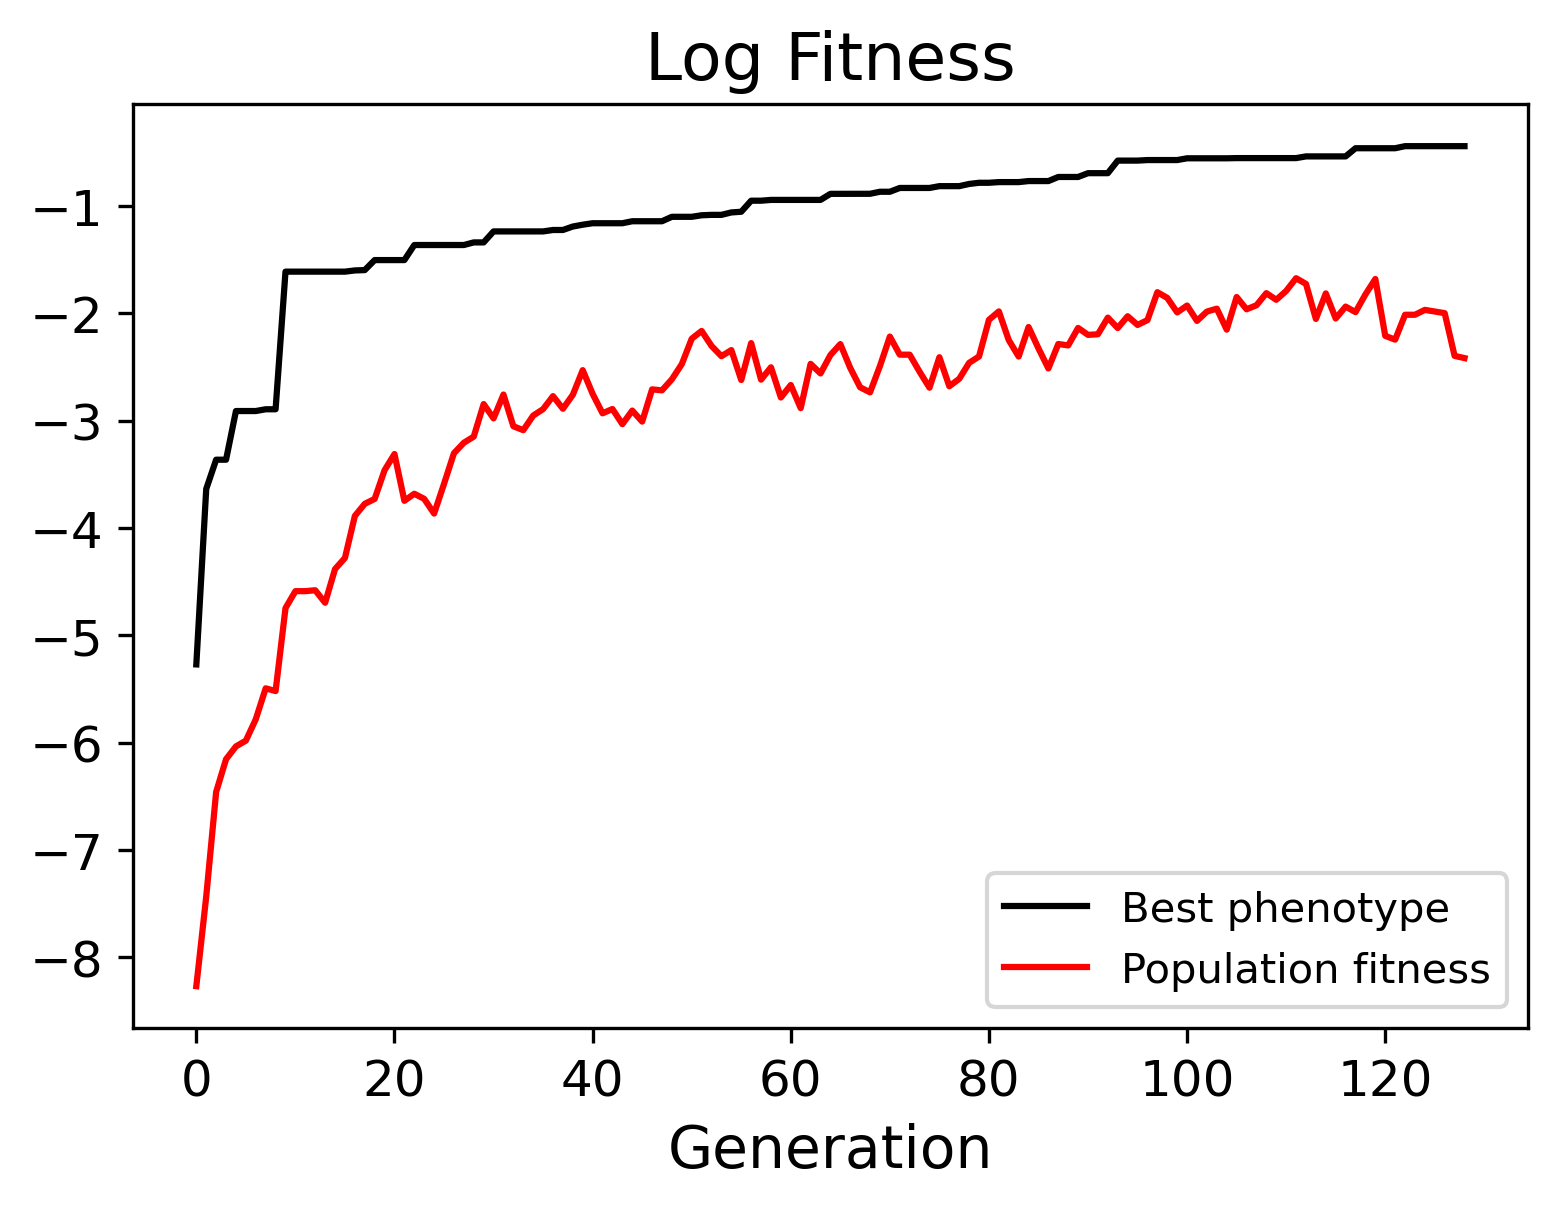

In [6]:
Image(filename=outputFolderName + '/EvoHist_fitness.png')

In [7]:
with open(outputFolderName + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

109.0 0.5752595025 0.1536307462 0.04310165435
110.0 0.5752595025 0.166888241 0.04559508196
111.0 0.5752595025 0.18785103 0.04762665931
112.0 0.5844478284 0.1781478373 0.04883327513
113.0 0.5844478284 0.1284873994 0.03797286915
114.0 0.5844478284 0.1630461991 0.04951468464
115.0 0.5844478284 0.1290623171 0.04115456715
116.0 0.5844478284 0.1442114809 0.0435197533
117.0 0.6306740163 0.1369771157 0.04575002966
118.0 0.6306740163 0.1615051206 0.04888544095
119.0 0.6306740163 0.1864649922 0.05526711356
120.0 0.6306740163 0.1097939719 0.03766610738
121.0 0.6306740163 0.1059682228 0.03529939189
122.0 0.6429400697 0.1336461409 0.04348375848
123 0.6429400697 0.1336461409 0.04348375848
124 0.6429401049 0.1398392561 0.05184089101
125 0.6429401049 0.1377718663 0.05327166167
126 0.6429401049 0.1356600827 0.053736015
127 0.6429401049 0.09111436707 0.04056113506
128 0.6429401049 0.08923715965 0.03389797559



In the above evolution although the "popSize" parameter was set to 10 this was ignored by the actual execution because a checkpoint 'CPT' file was found in the directory (which had been copied from the input folder). In this case all the evolution parameters, except for the maximum number of generations, are set from this CPT file.

In [8]:
print(json.dumps(new_json_data['Evolutionary Optimization Parameters']['PopulationSize'], indent=2))

{
  "value": 66
}


To force the model to use the reduced "popSize" we need to set the "doCPT" parameter to false. In this case the entire worm population is initialized from the best fit worm parameter values which are stored in the JSON file. We also want to continue the evolution from the new output folder so we make sure to unset the 'inputFolderName' parameter:

Directory 'notebooks/example_W2D18L_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '20', '--max_generations', '5', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR', '-docpt', '0']
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
construct from best gene notebooks/example_W2D18L_evo/best.gen.dat with gene size 30
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo/body.dat
Saved plot image to: notebooks/example_W2D18L_evo/ExampleActiv

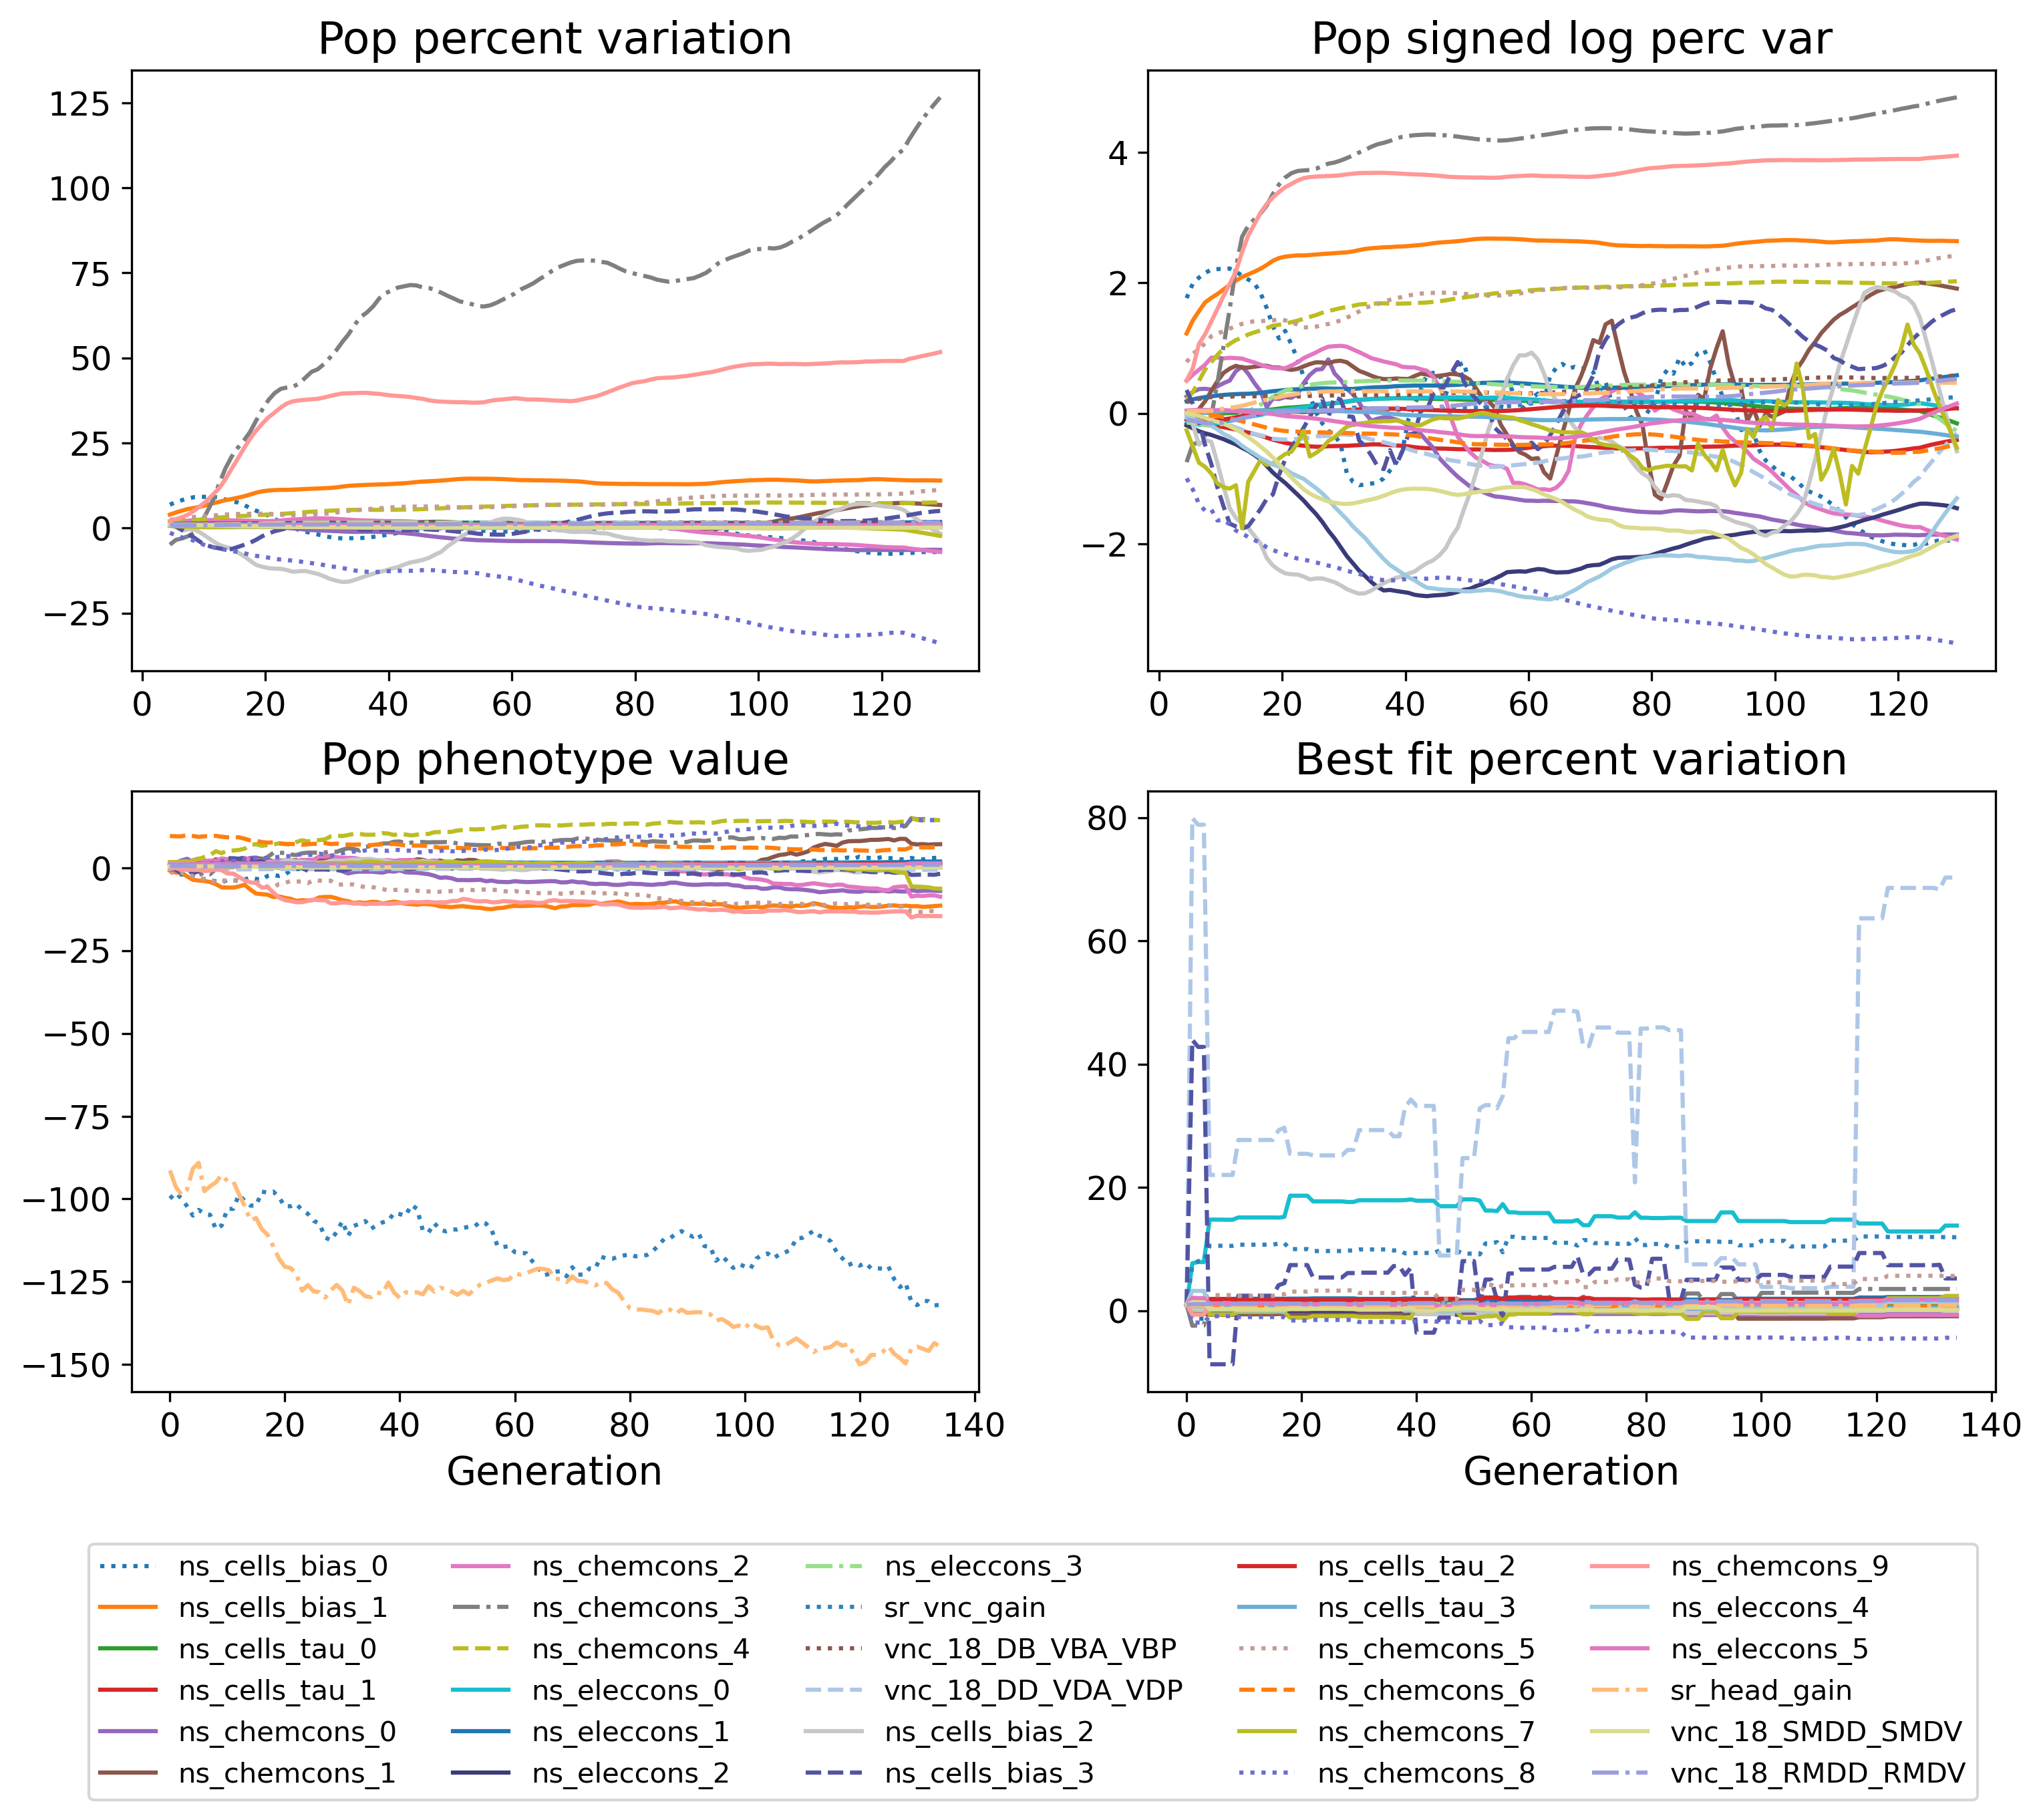

In [9]:
args['inputFolderName']=None
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=5 #run the optimization for ten more generations 
args['popSize']=20 #population size for optimization
args["doCPT"]=False
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

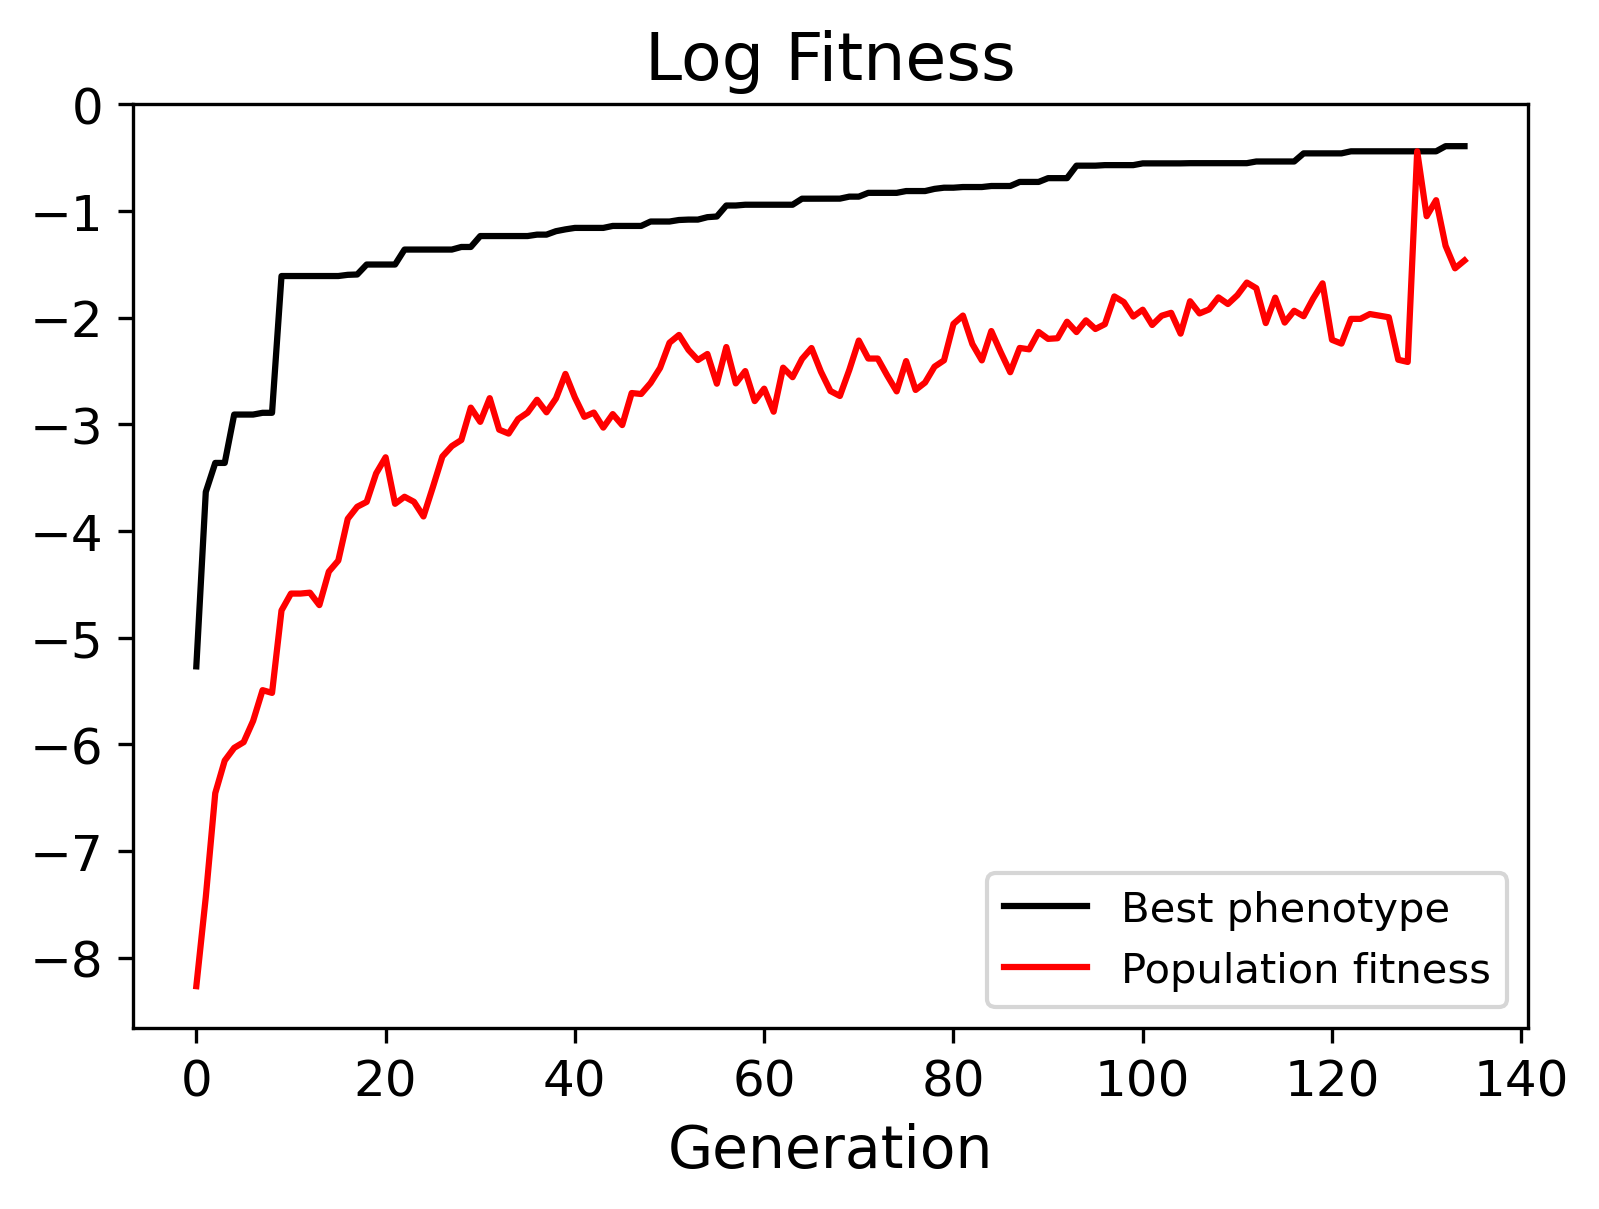

In [10]:
Image(filename=outputFolderName + '/EvoHist_fitness.png')

In [11]:
with open(outputFolderName + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

115.0 0.5844478284 0.1290623171 0.04115456715
116.0 0.5844478284 0.1442114809 0.0435197533
117.0 0.6306740163 0.1369771157 0.04575002966
118.0 0.6306740163 0.1615051206 0.04888544095
119.0 0.6306740163 0.1864649922 0.05526711356
120.0 0.6306740163 0.1097939719 0.03766610738
121.0 0.6306740163 0.1059682228 0.03529939189
122.0 0.6429400697 0.1336461409 0.04348375848
123.0 0.6429400697 0.1336461409 0.04348375848
124.0 0.6429401049 0.1398392561 0.05184089101
125.0 0.6429401049 0.1377718663 0.05327166167
126.0 0.6429401049 0.1356600827 0.053736015
127.0 0.6429401049 0.09111436707 0.04056113506
128.0 0.6429401049 0.08923715965 0.03389797559
129 0.6429401049 0.6429401049 0
130 0.6429401049 0.3499308555 0.0853358659
131 0.6429488403 0.4066104581 0.07482776315
132 0.674730022 0.2650647661 0.08068208009
133 0.674730022 0.2146977562 0.06793586824
134 0.674730022 0.2310403651 0.08285911261



In [12]:
print(json.dumps(new_json_data['Evolutionary Optimization Parameters']['PopulationSize'], indent=2))

{
  "value": 20
}


In [ ]:
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=5 #run the optimization for ten more generations 
args['popSize']=30 #population size for optimization
args["doCPT"]=False
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

Directory 'notebooks/example_W2D18L_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '30', '--max_generations', '5', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR', '-docpt', '0']


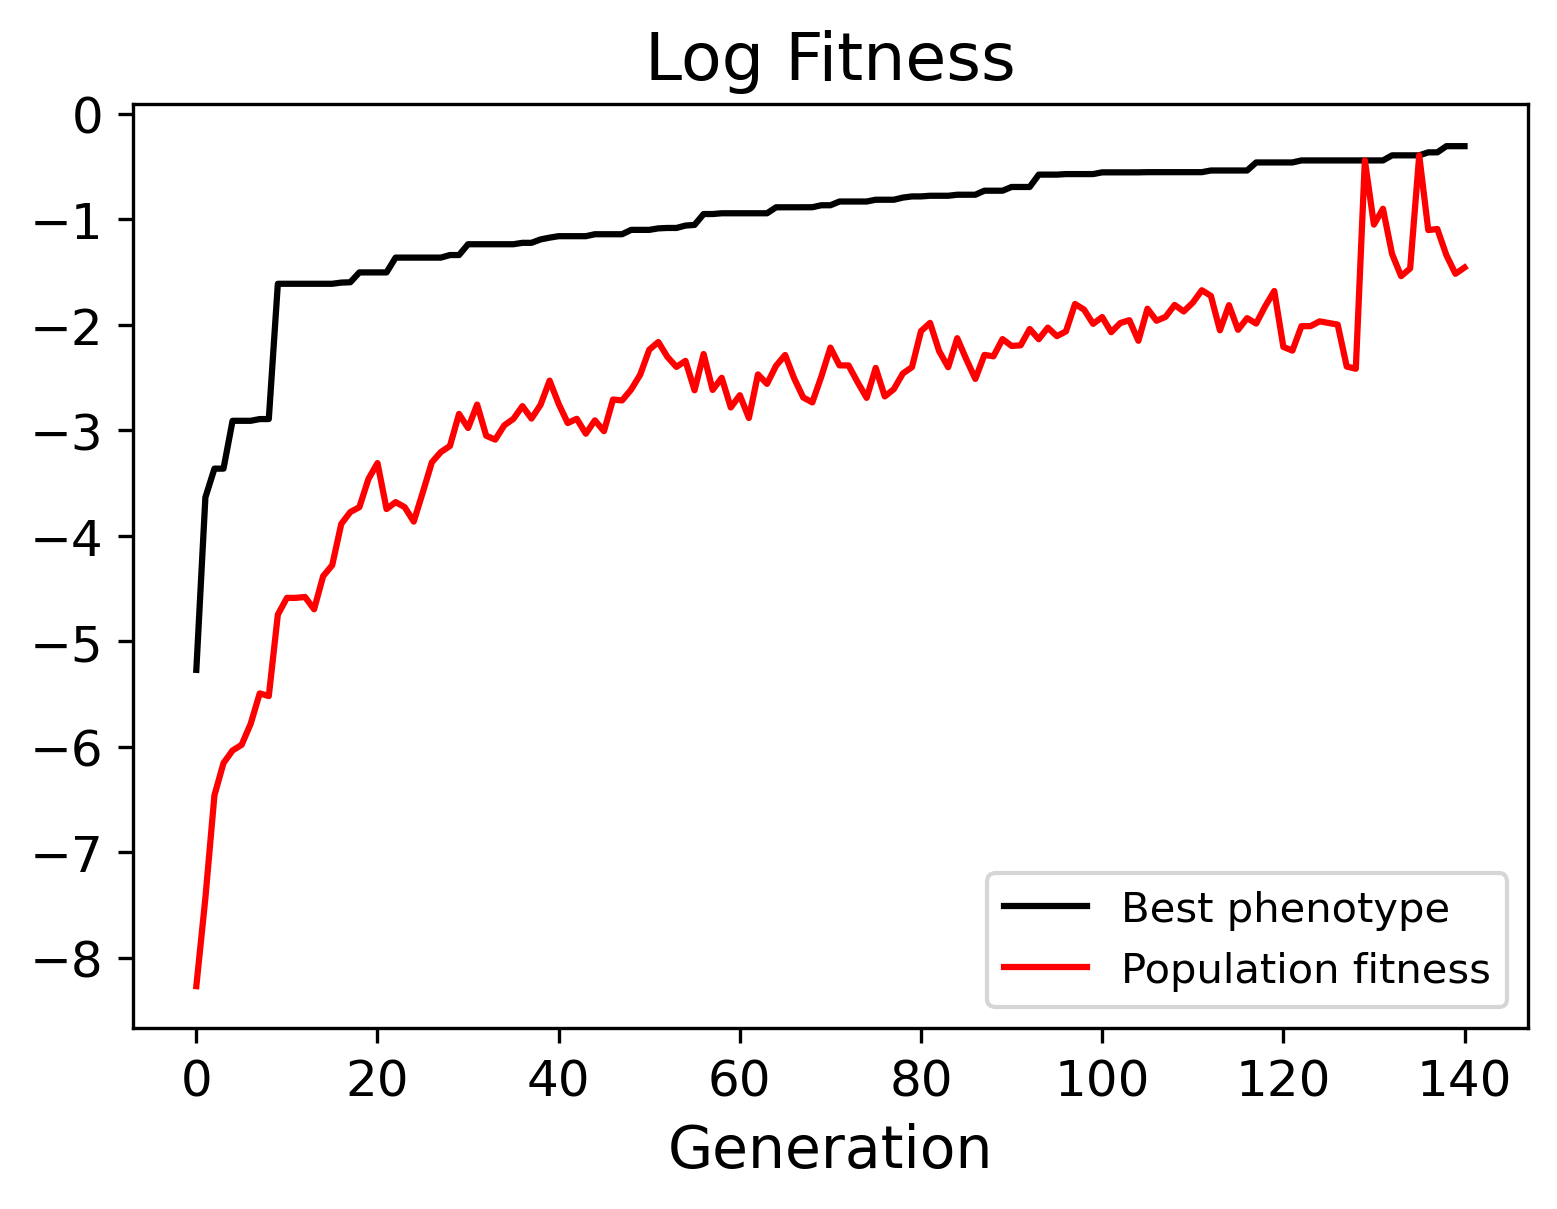

In [18]:
Image(filename=outputFolderName + '/EvoHist_fitness.png')

In [16]:
with open(outputFolderName + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

121.0 0.6306740163 0.1059682228 0.03529939189
122.0 0.6429400697 0.1336461409 0.04348375848
123.0 0.6429400697 0.1336461409 0.04348375848
124.0 0.6429401049 0.1398392561 0.05184089101
125.0 0.6429401049 0.1377718663 0.05327166167
126.0 0.6429401049 0.1356600827 0.053736015
127.0 0.6429401049 0.09111436707 0.04056113506
128.0 0.6429401049 0.08923715965 0.03389797559
129.0 0.6429401049 0.6429401049 0.0
130.0 0.6429401049 0.3499308555 0.0853358659
131.0 0.6429488403 0.4066104581 0.07482776315
132.0 0.674730022 0.2650647661 0.08068208009
133.0 0.674730022 0.2146977562 0.06793586824
134.0 0.674730022 0.2310403651 0.08285911261
135 0.674730022 0.674730022 0
136 0.6940834554 0.332208016 0.1141751642
137 0.6940834554 0.3356867763 0.09930887693
138 0.7360180085 0.2619342322 0.09592897389
139 0.7360180085 0.219604521 0.09009516042
140 0.7360180085 0.2329554367 0.09013563636



In [17]:
print(json.dumps(new_json_data['Evolutionary Optimization Parameters']['PopulationSize'], indent=2))

{
  "value": 30
}


When doCPT is set to True again the evolution will resume from the last checkpoint file, which here has a population size of 30 according to the last evolutionary simulation: 

Directory 'notebooks/example_W2D18L_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '40', '--max_generations', '5', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR', '-docpt', '1']
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_evo/search.cpt with size 30
setting  population size to cpt population size: 30
Resuming search
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo/body.dat
Saved p

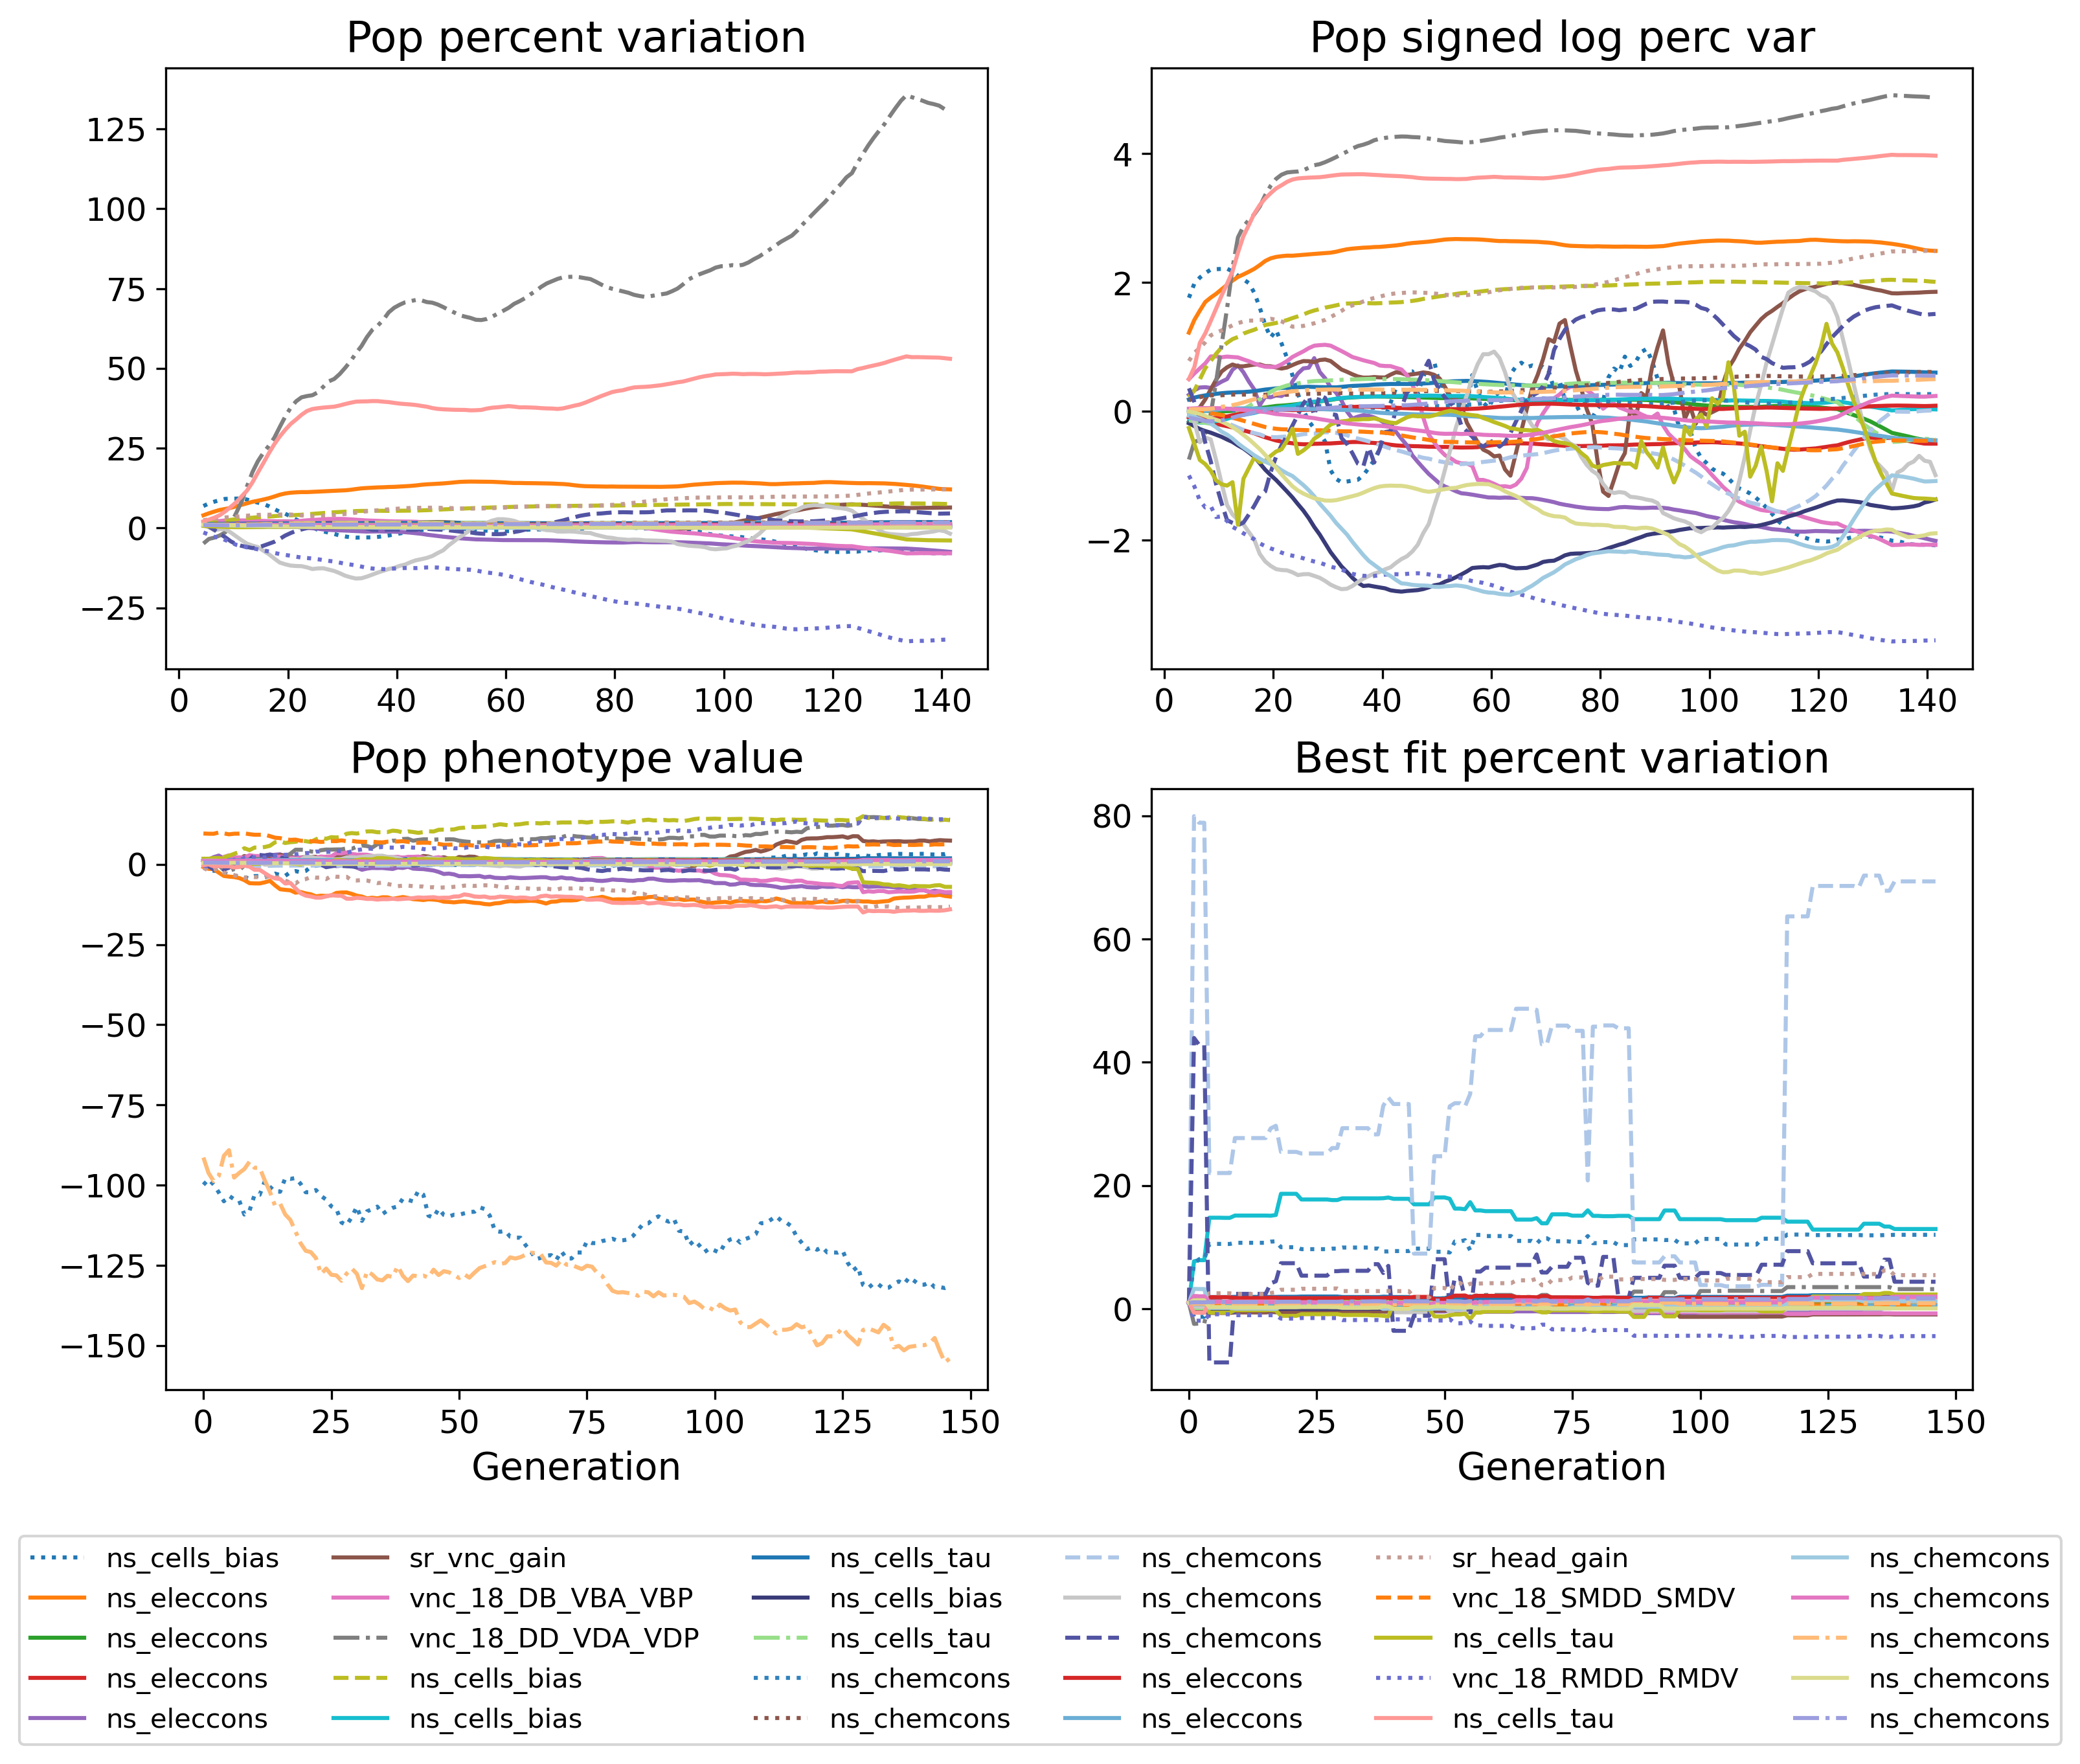

In [19]:
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=5 #run the optimization for ten more generations 
args['popSize']=40 #population size for optimization
args["doCPT"]=True
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

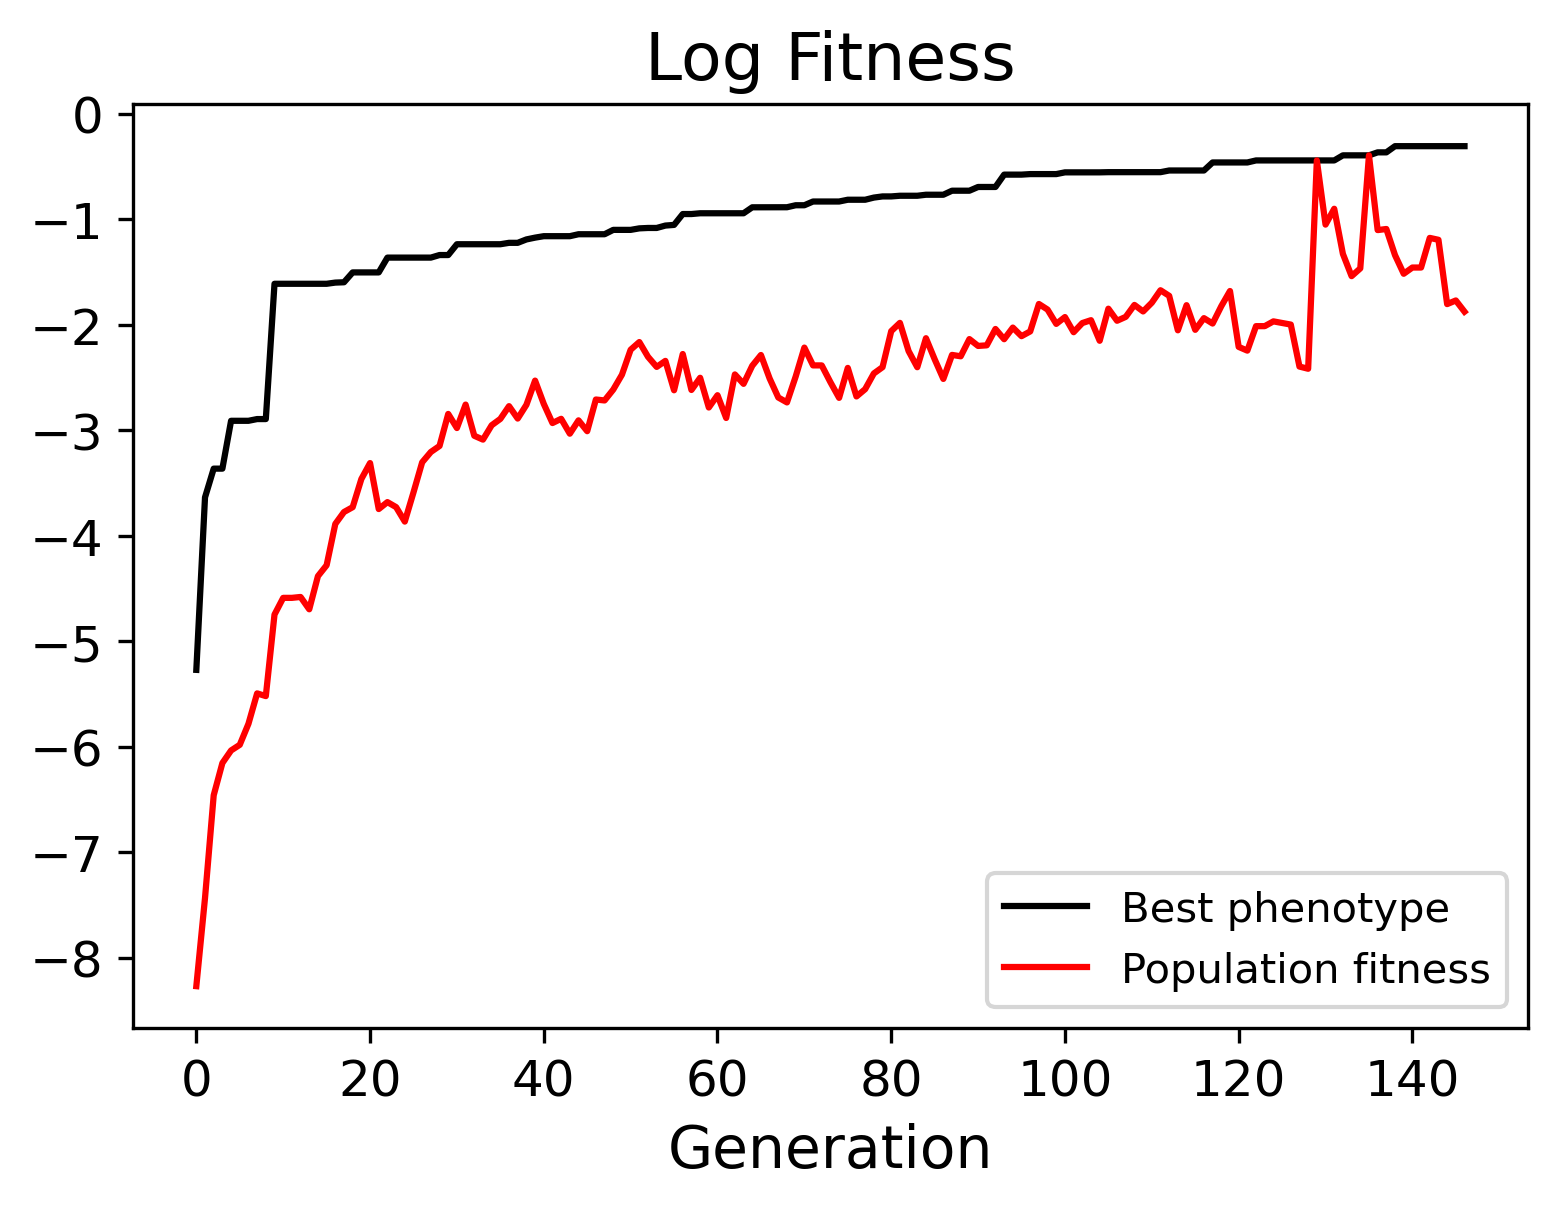

In [20]:
Image(filename=outputFolderName + '/EvoHist_fitness.png')

In [21]:
with open(outputFolderName + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

127.0 0.6429401049 0.09111436707 0.04056113506
128.0 0.6429401049 0.08923715965 0.03389797559
129.0 0.6429401049 0.6429401049 0.0
130.0 0.6429401049 0.3499308555 0.0853358659
131.0 0.6429488403 0.4066104581 0.07482776315
132.0 0.674730022 0.2650647661 0.08068208009
133.0 0.674730022 0.2146977562 0.06793586824
134.0 0.674730022 0.2310403651 0.08285911261
135.0 0.674730022 0.674730022 0.0
136.0 0.6940834554 0.332208016 0.1141751642
137.0 0.6940834554 0.3356867763 0.09930887693
138.0 0.7360180085 0.2619342322 0.09592897389
139.0 0.7360180085 0.219604521 0.09009516042
140.0 0.7360180085 0.2329554367 0.09013563636
141 0.7360180085 0.2329554367 0.09013563636
142 0.7360180085 0.3085039749 0.1098384623
143 0.7360180085 0.3030036972 0.104573389
144 0.7360180085 0.1647176985 0.07948042107
145 0.7360180085 0.1704814333 0.0832548784
146 0.7360180085 0.1532692409 0.08007784583



In [22]:
print(json.dumps(new_json_data['Evolutionary Optimization Parameters']['PopulationSize'], indent=2))

{
  "value": 30
}


The optimizable parameters are indicated in the 'evolvable_ranges' object of the JSON file. Each entry has an 'evotag' which indicates which worm parameters it represents (see below). The parameter can vary within the prescribed upper and lower limits. Each entry also has a name which is not unique indicating the type of parameter it is. There may be several different optimizable cell bias parameters, for example. A parameter can be set to be inactive to remove it from the optimization.  

In [23]:
print(json.dumps(new_json_data['evolvable_ranges'], indent=2))

{
  "evotag_1": {
    "active": true,
    "lower_limit": -15.0,
    "name": "ns_cells_bias",
    "upper_limit": 15.0
  },
  "evotag_10": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_11": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_12": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_13": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_14": {
    "active": true,
    "lower_limit": -200.0,
    "name": "sr_vnc_gain",
    "upper_limit": 0.0
  },
  "evotag_15": {
    "active": true,
    "lower_limit": 0.0,
    "name": "vnc_18_DB_VBA_VBP",
    "upper_limit": 1.0
  },
  "evotag_16": {
    "active": true,
    "lower_limit": -1.0,
    "name": "vnc_18_DD_VDA_VDP",
    "upper_limit": 0.0
  },
  "evotag_17": {
    "active": true,
    "lower_li

The 'evotags' can be found in the json configuration file next to the value they correspond to. For example cells VDP_0 and VDP_1 both contain the 'evotag_2' in their bias field, which means both these biases will be set to the same value and this value will be optimized. Their 'tau' fields are also the same and optimized. The 'values' set in the json file are those taken from the best fit worm.

In [24]:
print('VDP_0: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_0'], indent=2))
print('VDP_1: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_1'], indent=2))

VDP_0: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.1527777777777778
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 0.6624710604772114
  }
}
VDP_1: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.3194444444444444
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 0.6624710604772114
  }
}


After an evolution these values may be changed if the best fit worm is changed:

Directory 'notebooks/example_W2D18L_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '40', '--max_generations', '10', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR', '-docpt', '1']
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_evo/search.cpt with size 30
setting  population size to cpt population size: 30
Resuming search
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo/body.dat
Saved 

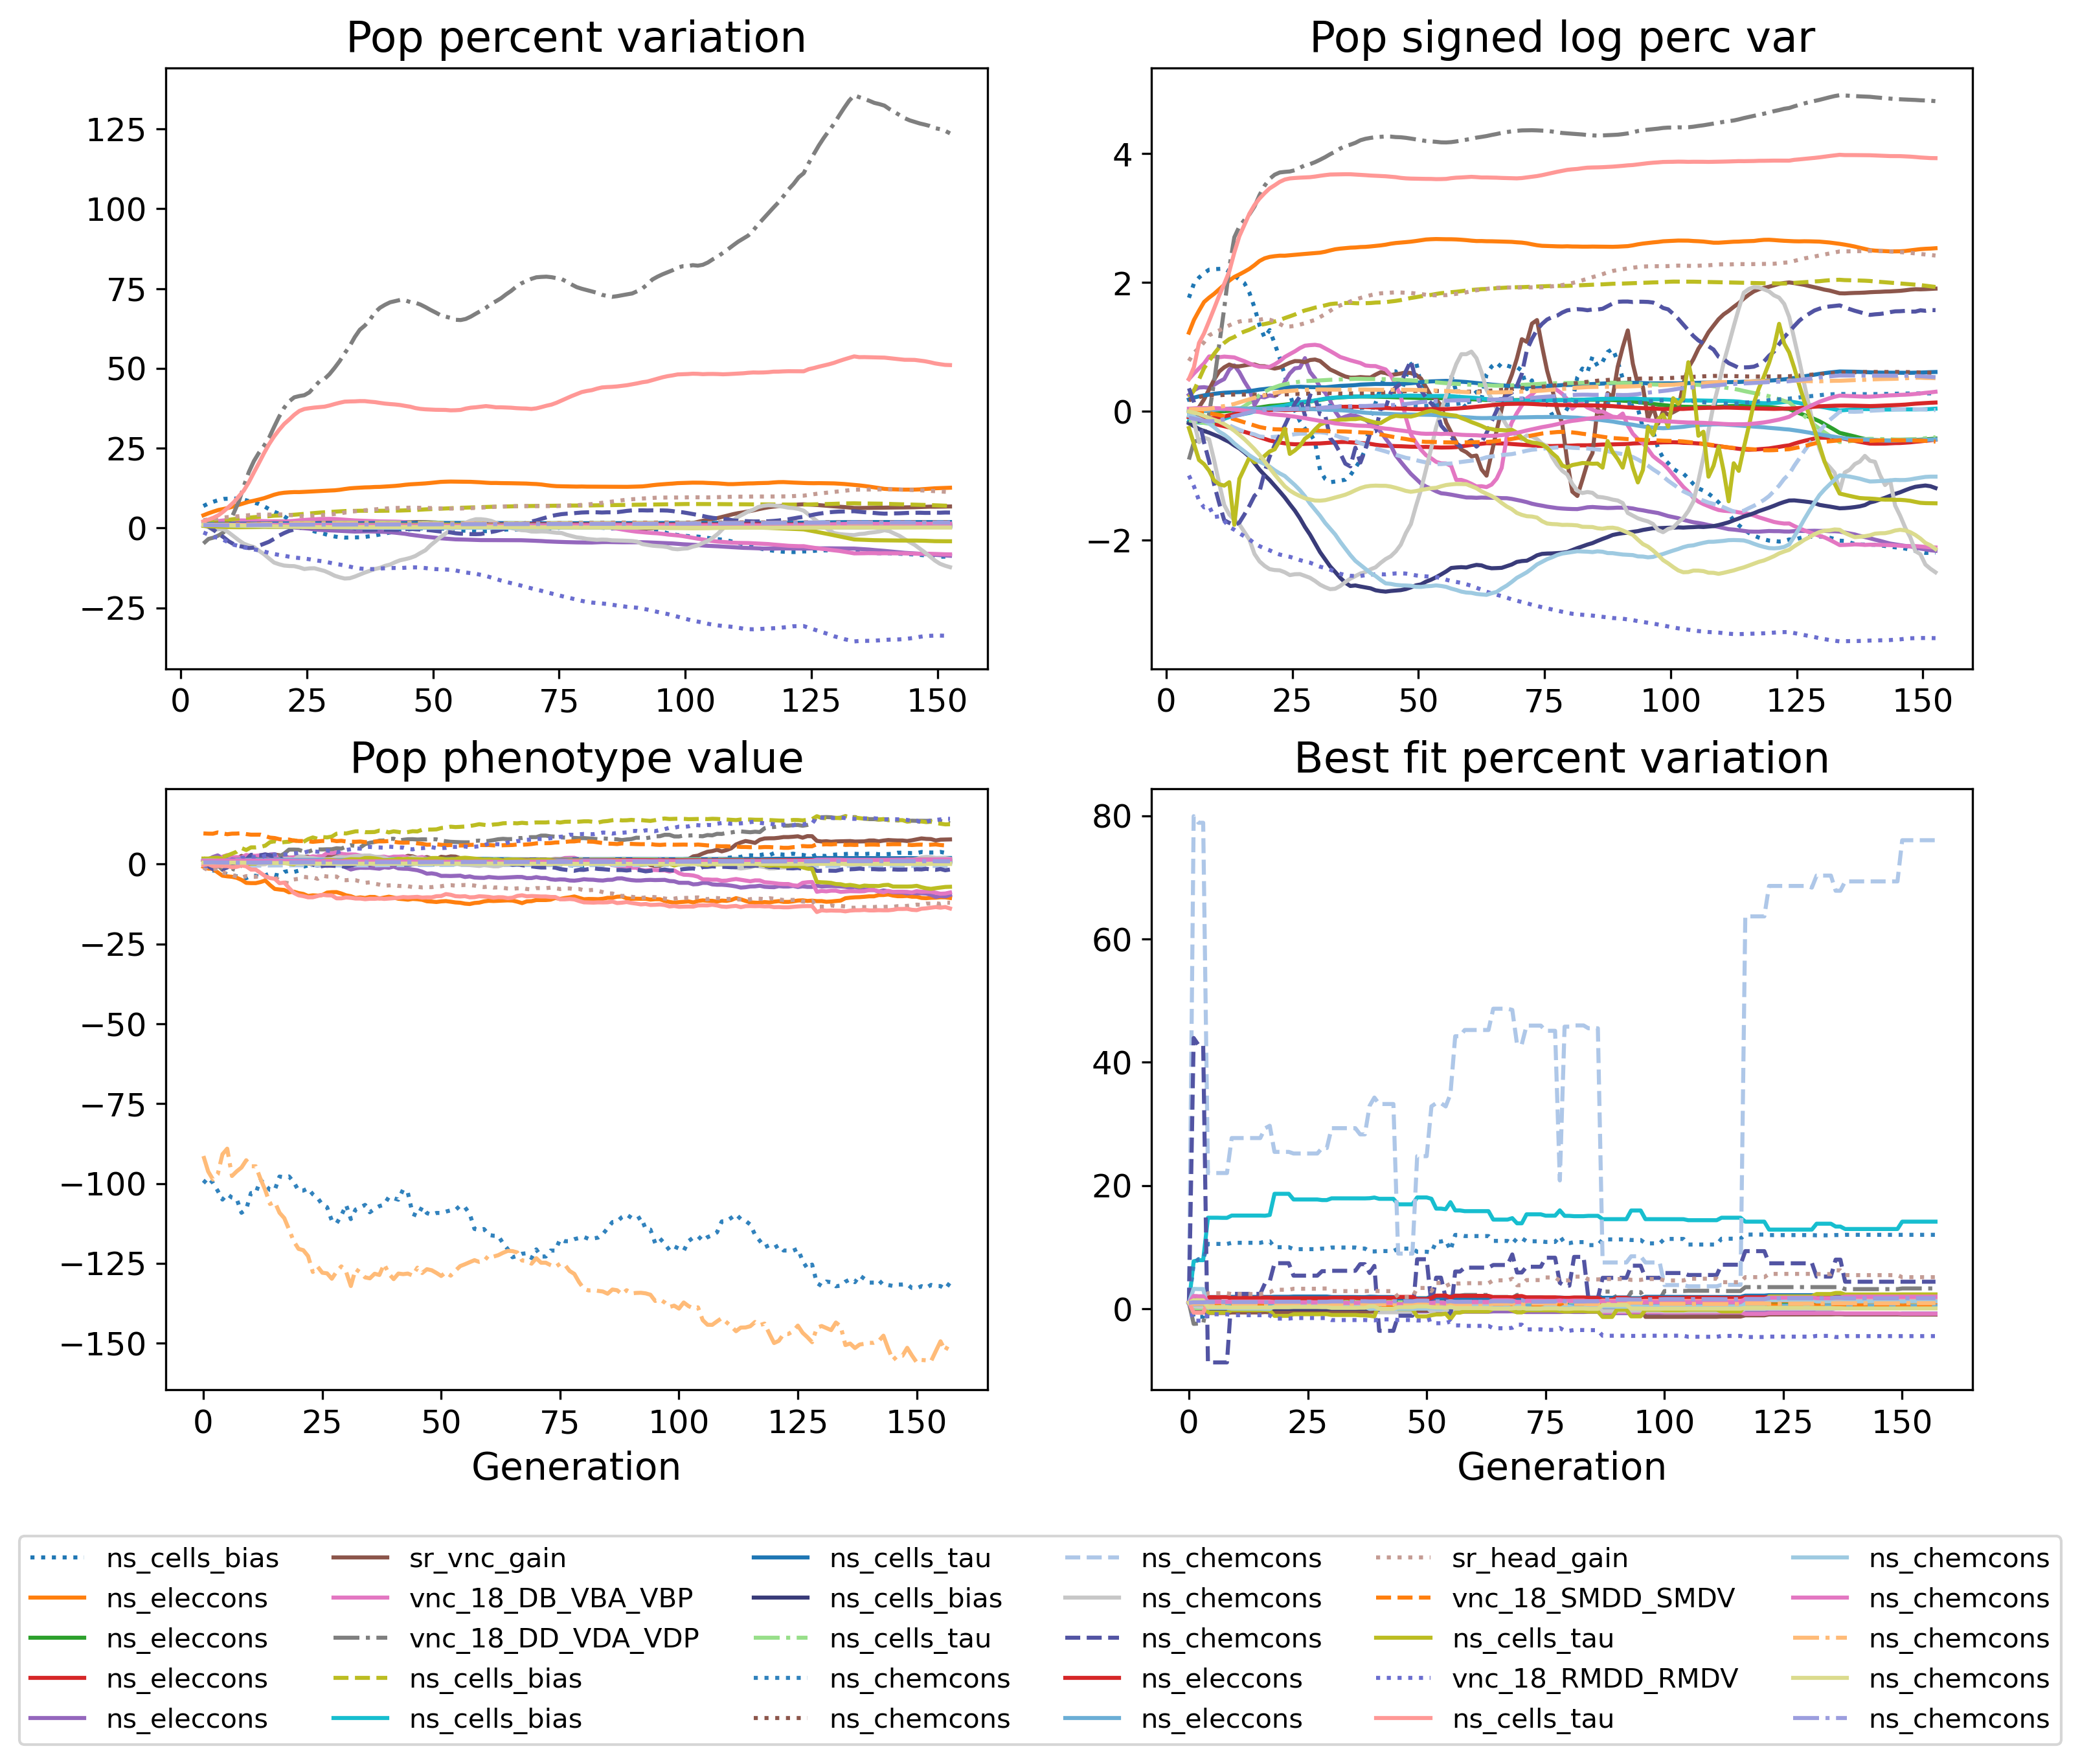

In [25]:
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=10 #run the optimization for ten more generations 
args["doCPT"]=True
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

In [28]:
with open(outputFolderName + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

138.0 0.7360180085 0.2619342322 0.09592897389
139.0 0.7360180085 0.219604521 0.09009516042
140.0 0.7360180085 0.2329554367 0.09013563636
141.0 0.7360180085 0.2329554367 0.09013563636
142.0 0.7360180085 0.3085039749 0.1098384623
143.0 0.7360180085 0.3030036972 0.104573389
144.0 0.7360180085 0.1647176985 0.07948042107
145.0 0.7360180085 0.1704814333 0.0832548784
146.0 0.7360180085 0.1532692409 0.08007784583
147 0.7360180085 0.1532692409 0.08007784583
148 0.7360180085 0.2537641229 0.1006045091
149 0.7360180085 0.299529041 0.1025940897
150 0.7409220564 0.191092382 0.08350553459
151 0.7409220564 0.1900321943 0.08701850708
152 0.7409220564 0.1769649013 0.07089847307
153 0.7409220564 0.2184956758 0.0815110942
154 0.7409220564 0.1638320198 0.07515640094
155 0.7409220564 0.1905028483 0.08032983388
156 0.7409220564 0.182044949 0.06784685851
157 0.7409220564 0.1868814749 0.07145504492



These parameters have different values from before the latest optimization run:

In [29]:
print('VDP_0: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_0'], indent=2))
print('VDP_1: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_1'], indent=2))

VDP_0: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.1527777777777778
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 0.6624710604772114
  }
}
VDP_1: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.3194444444444444
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 0.6624710604772114
  }
}


An optimizable parameter can be turned off:

In [30]:
print(json.dumps(new_json_data['evolvable_ranges']['evotag_2'], indent=2))
new_json_data['evolvable_ranges']['evotag_2']["active"] = False
print(json.dumps(new_json_data['evolvable_ranges']['evotag_2'], indent=2))

{
  "active": true,
  "lower_limit": -15.0,
  "name": "ns_cells_bias",
  "upper_limit": 15.0
}
{
  "active": false,
  "lower_limit": -15.0,
  "name": "ns_cells_bias",
  "upper_limit": 15.0
}


If the optizable parameters change the evolution history figures must be restarted and the evolution will initialize from the existing parameters of the best genotype. To avoid losing previous figures we make a new output directory and set the old one as the input directory. Also make sure to save the modified json to the new output directory before running the optimization: 

Directory 'notebooks/example_W2D18L_evo_2' already exists and all the contents will be overwritten.
Input evolution history will not be copied because active evolvable_ranges evotags in notebooks/example_W2D18L_evo_2/worm_data_worm.json do not match evolved_used.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '40', '--max_generations', '10', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo_2', '--modelname', 'W2DSR', '-docpt', '0']
jsonfile notebooks/example_W2D18L_evo_2/worm_data_worm.json
jsonfile notebooks/example_W2D18L_evo_2/worm_data_worm.json
Previous evolution files are not evotag-compatible with notebooks/example_W2D18L_evo_2/worm_data_worm.json because active evolvable_ranges evotags do not match evolved_used
construct from best gene notebooks/example_W2D18L_evo_2/EvoWJbest.gen.dat with gene size 29
jsonfile notebooks/example_W2D18L_evo_2/worm_data_evo.json
jsonfile notebooks/exampl

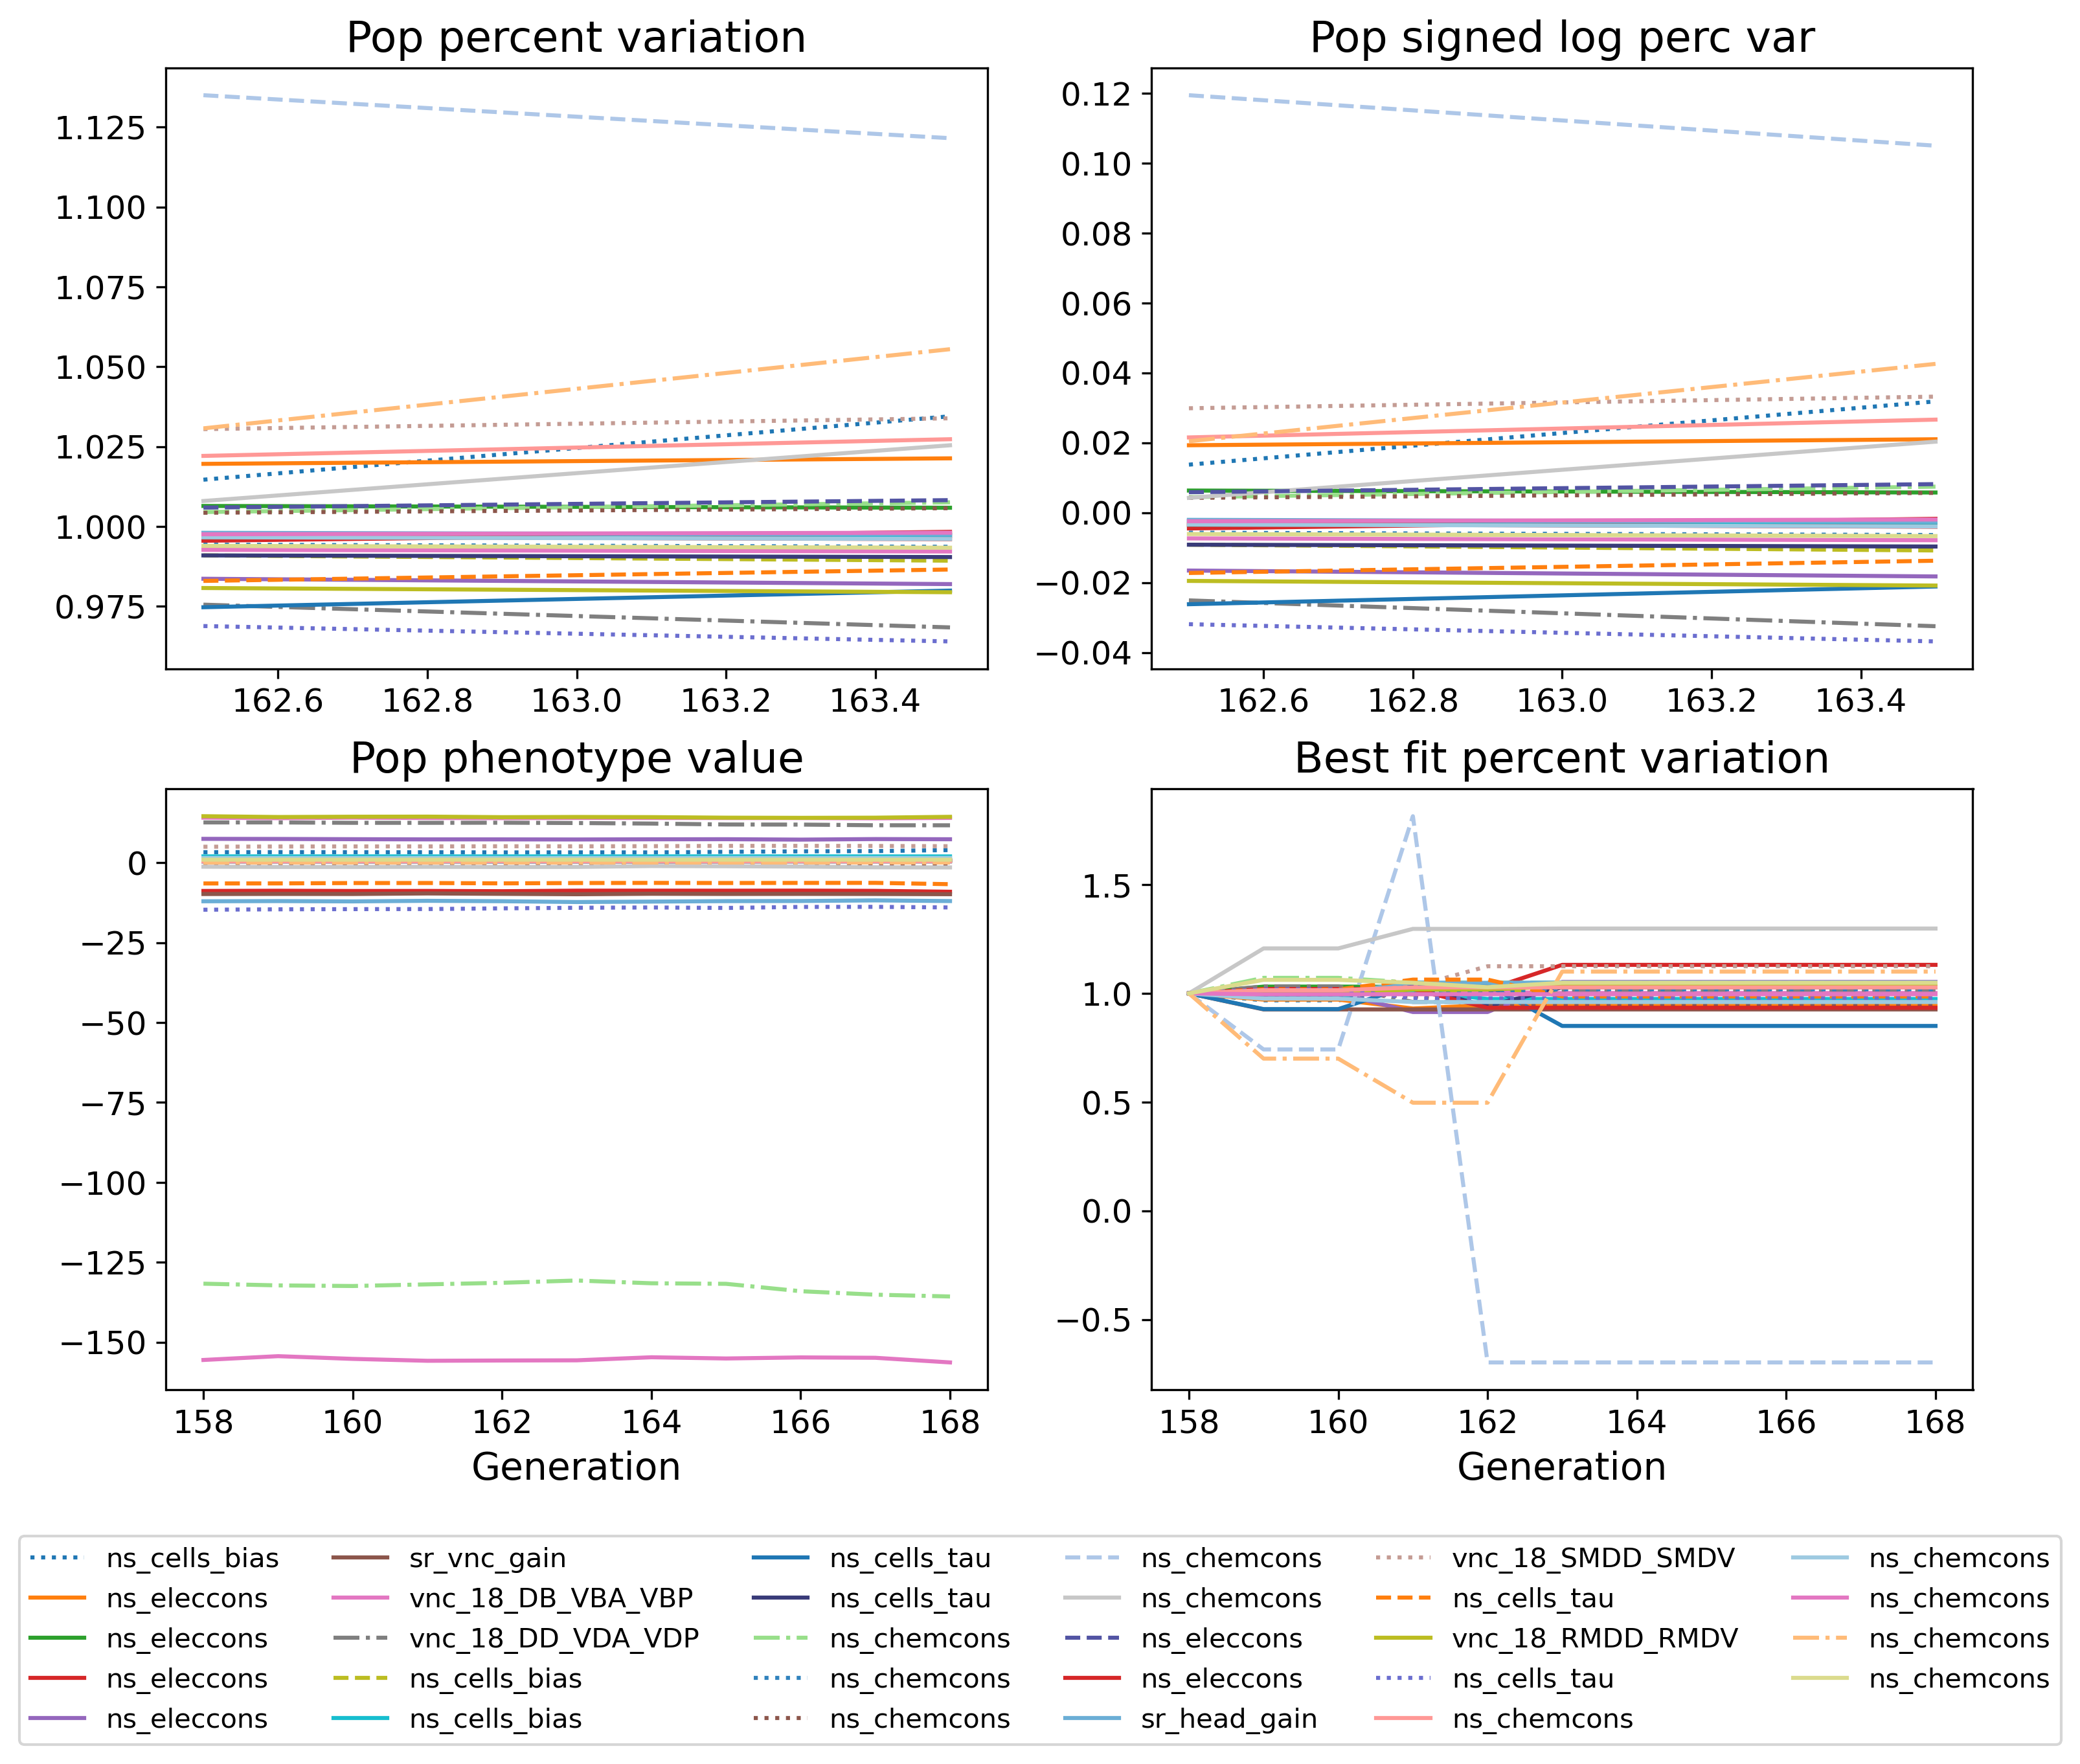

In [32]:
outputFolderName_2=origFolderName + "_evo_2"
write_worm_json(outputFolderName_2, new_json_data)
args['inputFolderName']= outputFolderName
args['outputFolderName']= outputFolderName_2
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=10 #run the optimization for ten more generations 
args['doCPT']=True
run(**args)
new_json_data = get_worm_json(outputFolderName_2)
Image(filename=outputFolderName_2 + '/EvoHist.png')

In [34]:
with open(outputFolderName_2 + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

149.0 0.7360180085 0.299529041 0.1025940897
150.0 0.7409220564 0.191092382 0.08350553459
151.0 0.7409220564 0.1900321943 0.08701850708
152.0 0.7409220564 0.1769649013 0.07089847307
153.0 0.7409220564 0.2184956758 0.0815110942
154.0 0.7409220564 0.1638320198 0.07515640094
155.0 0.7409220564 0.1905028483 0.08032983388
156.0 0.7409220564 0.182044949 0.06784685851
157.0 0.7409220564 0.1868814749 0.07145504492
158 0.7409220564 0.7409220564 0
159 0.7501487314 0.460550354 0.1242903143
160 0.7501487314 0.4821433759 0.1078420299
161 0.7617104272 0.4206303353 0.118910476
162 0.7633379701 0.3494017939 0.120345141
163 0.7779236241 0.3460237386 0.1235382158
164 0.7779236241 0.2684563743 0.1131690293
165 0.7779236241 0.3264842523 0.1145458625
166 0.7779236241 0.2415574207 0.09668329091
167 0.7779236241 0.2025642934 0.09100317448
168 0.7779236241 0.2476084761 0.1053287589



Values labelled with 'evotag_2' should not be changed now.

In [35]:
print('VDP_0: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_0'], indent=2))
print('VDP_1: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_1'], indent=2))

VDP_0: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.1527777777777778
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 0.6822669305348098
  }
}
VDP_1: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.3194444444444444
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 0.6822669305348098
  }
}


Further simulations will initialize from the CPT file. Remember to unset the 'inputFolderName' to restart from the current directory: 

Directory 'notebooks/example_W2D18L_evo_2' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '40', '--max_generations', '10', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo_2', '--modelname', 'W2DSR', '-docpt', '1']
jsonfile notebooks/example_W2D18L_evo_2/worm_data_worm.json
jsonfile notebooks/example_W2D18L_evo_2/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_evo_2/search.cpt with size 29
Resuming search
jsonfile notebooks/example_W2D18L_evo_2/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo_2/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo_2/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo_2/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo_2/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo_2/body.dat
Saved plot image to: notebooks/examp

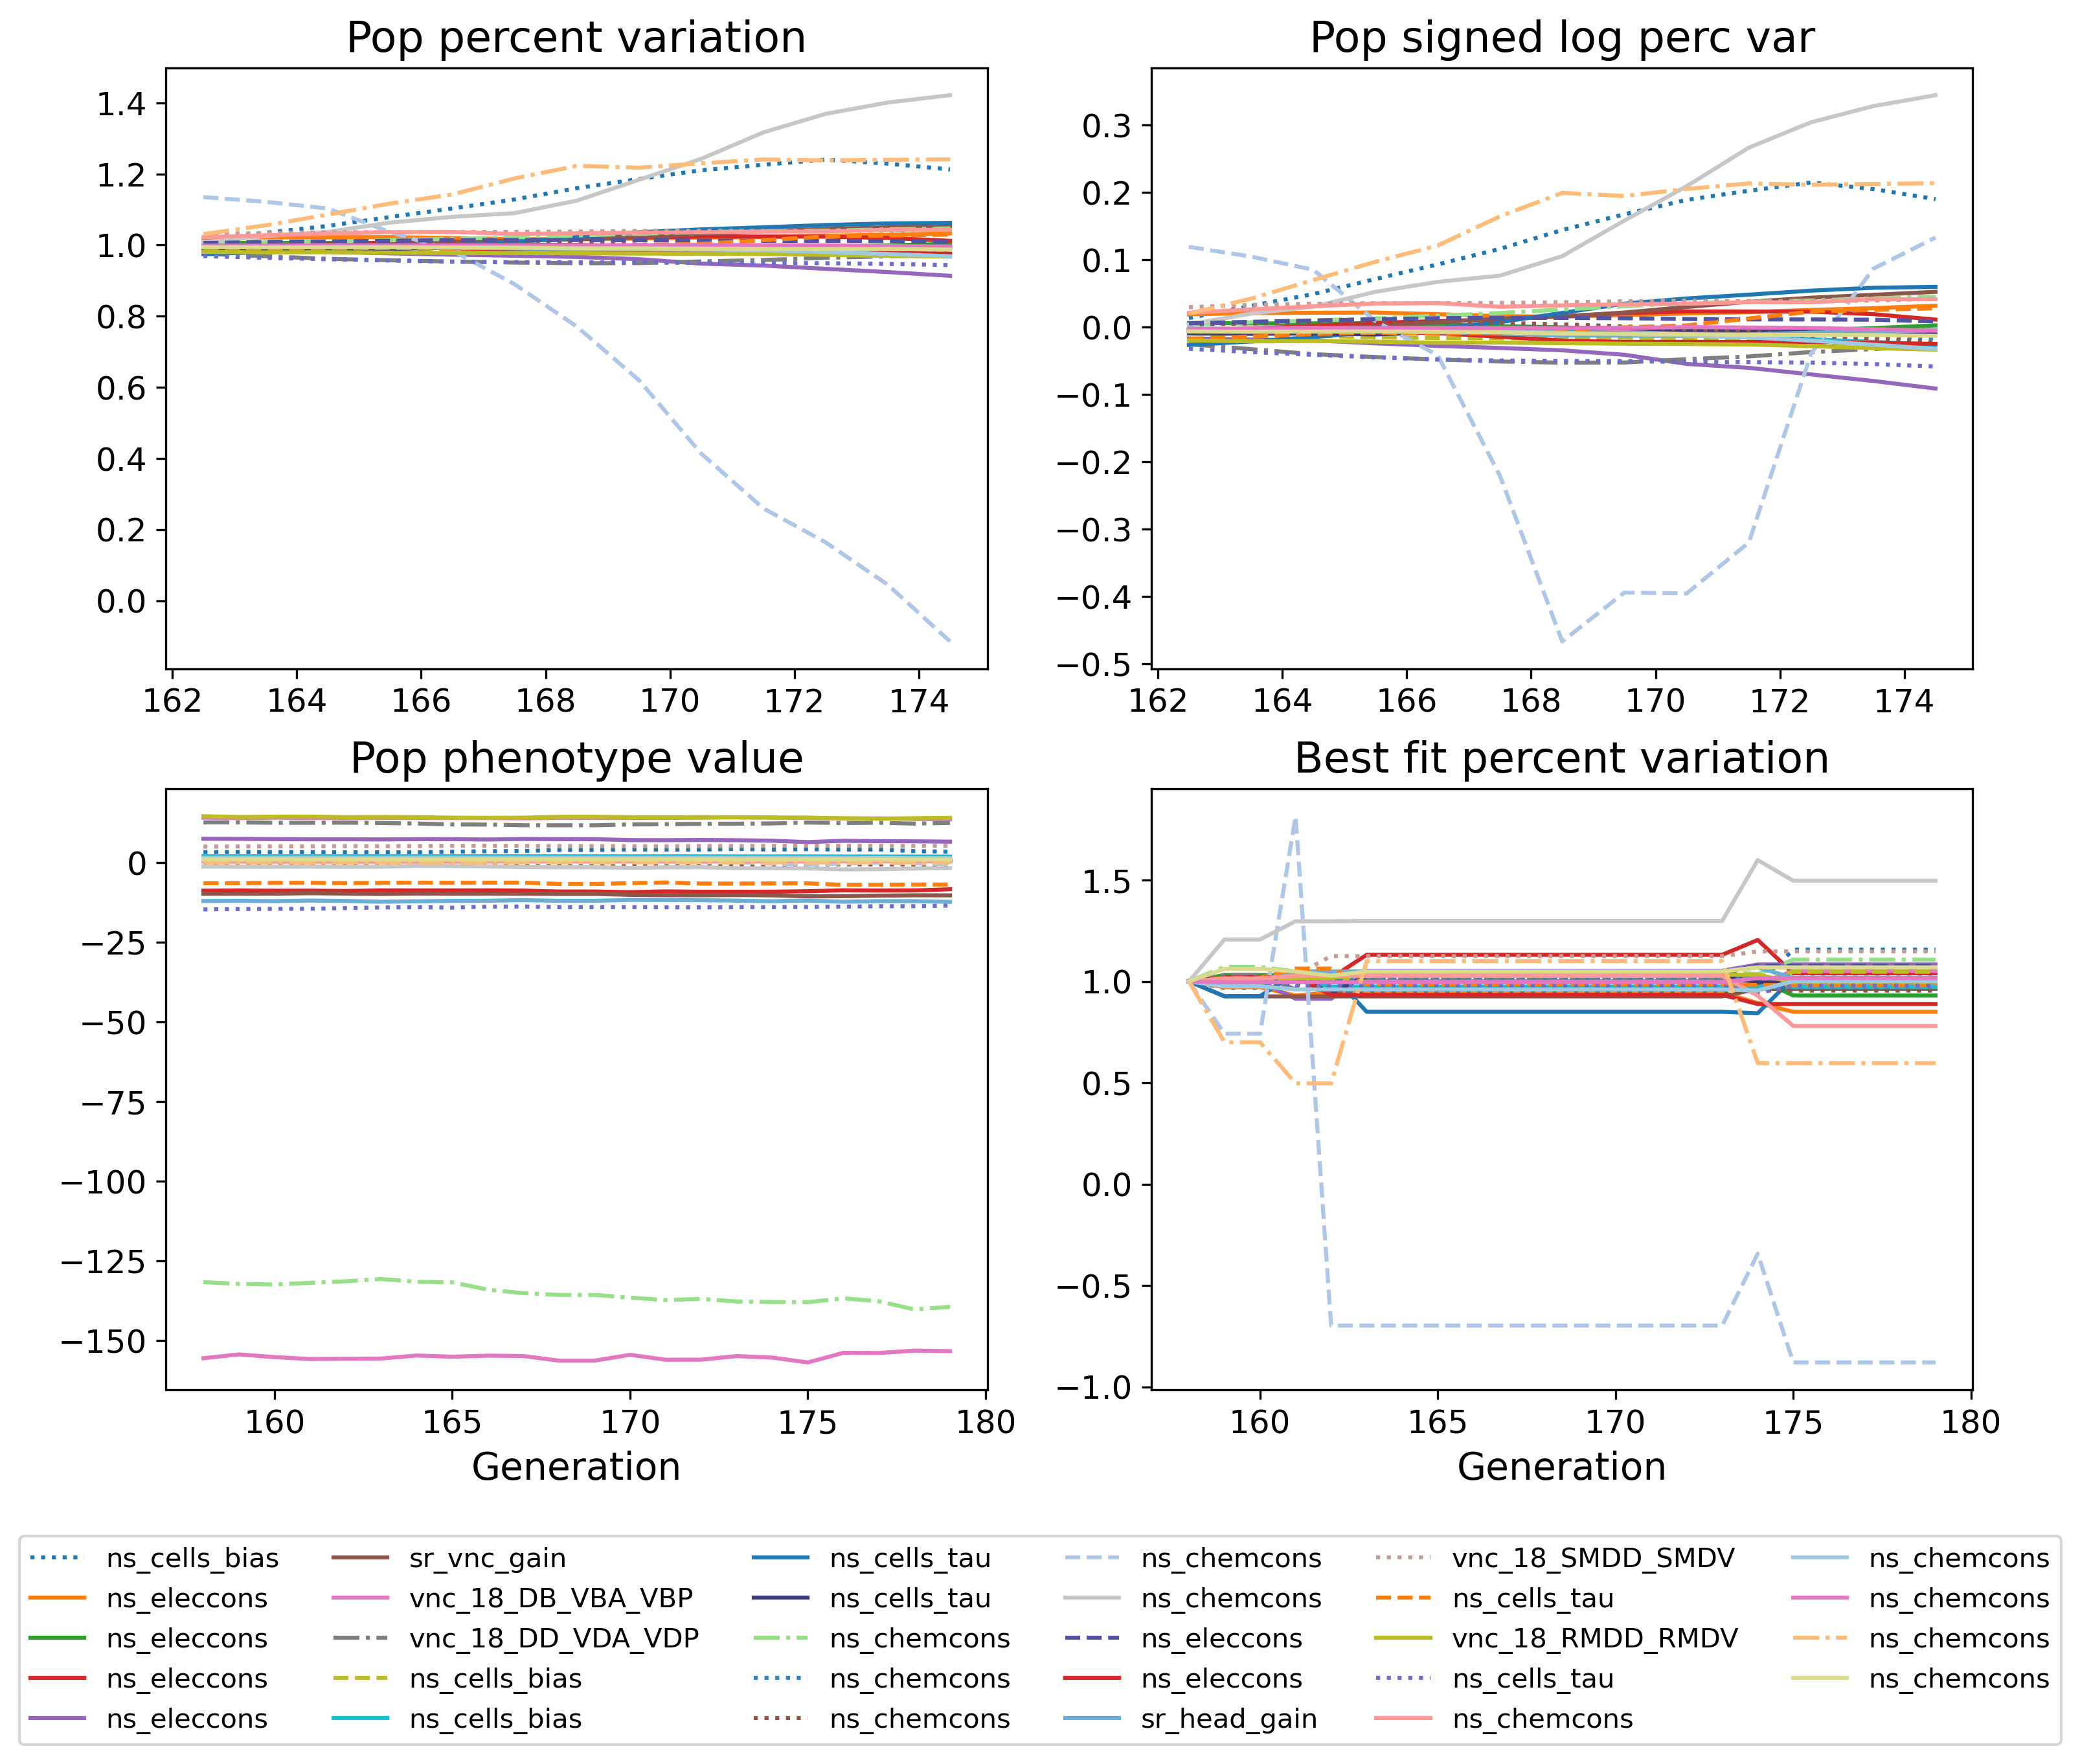

In [36]:
args['inputFolderName']= None
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=10 #run the optimization for ten more generations 
args["doCPT"]=True
run(**args)
new_json_data = get_worm_json(outputFolderName_2)
Image(filename=outputFolderName_2 + '/EvoHist.png')

In [38]:
print(json.dumps(new_json_data['evolvable_ranges']['evotag_4'], indent=2))
new_json_data['evolvable_ranges']['evotag_4']['upper_limit']=10
new_json_data['evolvable_ranges']['evotag_4']['lower_limit']=0.1
print(json.dumps(new_json_data['evolvable_ranges']['evotag_4'], indent=2))

{
  "active": true,
  "lower_limit": 0.5,
  "name": "ns_cells_tau",
  "upper_limit": 2.0
}
{
  "active": true,
  "lower_limit": 0.1,
  "name": "ns_cells_tau",
  "upper_limit": 10
}


Directory 'notebooks/example_W2D18L_evo_2' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '40', '--max_generations', '10', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo_2', '--modelname', 'W2DSR', '-docpt', '1']
jsonfile notebooks/example_W2D18L_evo_2/worm_data_worm.json
jsonfile notebooks/example_W2D18L_evo_2/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_evo_2/search.cpt with size 29
Resuming search
jsonfile notebooks/example_W2D18L_evo_2/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo_2/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo_2/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo_2/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo_2/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo_2/body.dat
Saved plot image to: notebooks/examp

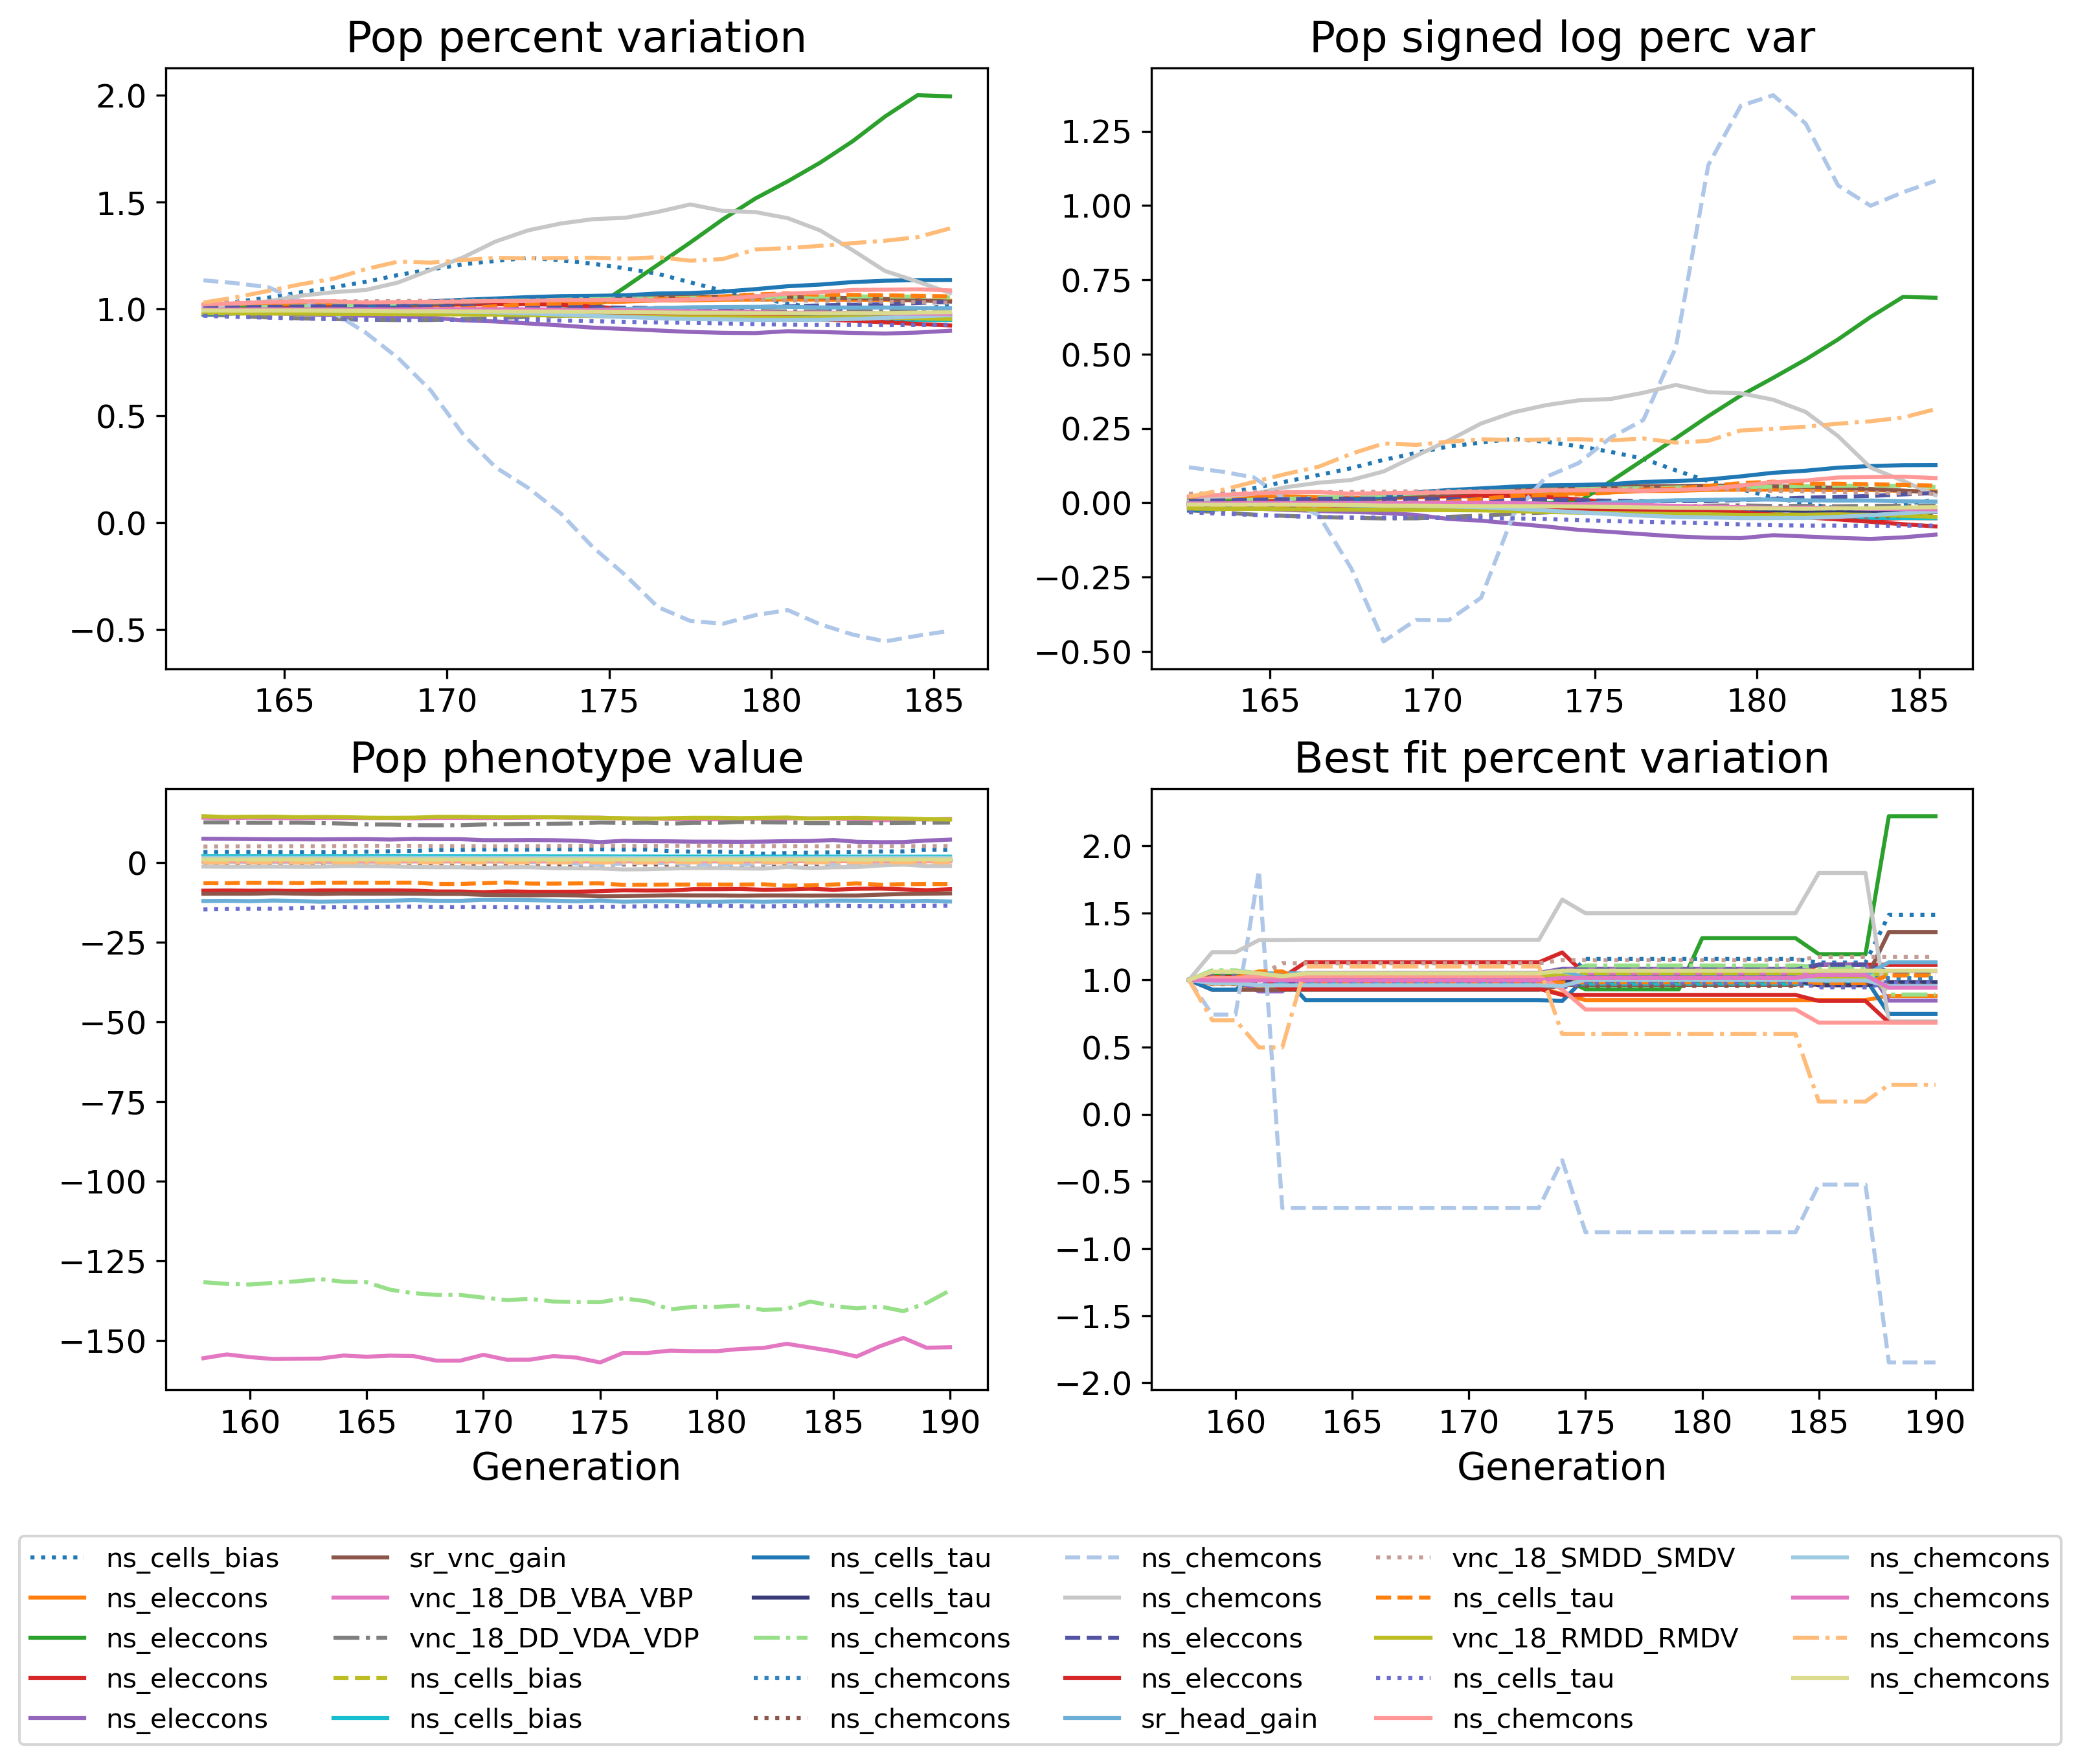

In [39]:
write_worm_json(outputFolderName_2, new_json_data)
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=10 #run the optimization for ten more generations 
run(**args)
new_json_data = get_worm_json(outputFolderName_2)
Image(filename=outputFolderName_2 + '/EvoHist.png')

In [40]:
print('VDP_0: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_0'], indent=2))
print('VDP_1: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_1'], indent=2))

VDP_0: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.1527777777777778
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 1.47013668687968
  }
}
VDP_1: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.3194444444444444
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 1.47013668687968
  }
}


In [54]:
import copy
new_json_data = get_worm_json(outputFolderName_2)
print(json.dumps(new_json_data['evolvable_ranges']['evotag_4'], indent=2))
new_json_data['evolvable_ranges']['VDP_0_tau'] = copy.deepcopy(new_json_data['evolvable_ranges']['evotag_4'])
new_json_data['evolvable_ranges']['VDP_0_tau']['name'] = 'VDP_0_tau'
print(json.dumps(new_json_data['evolvable_ranges']['VDP_0_tau'], indent=2))

{
  "active": true,
  "lower_limit": 0.1,
  "name": "ns_cells_tau",
  "upper_limit": 10
}
{
  "active": true,
  "lower_limit": 0.1,
  "name": "VDP_0_tau",
  "upper_limit": 10
}


In [55]:
print(json.dumps(new_json_data['evolvable_ranges'], indent=2))

{
  "evotag_1": {
    "active": true,
    "lower_limit": -15.0,
    "name": "ns_cells_bias",
    "upper_limit": 15.0
  },
  "evotag_10": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_11": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_12": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_13": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_14": {
    "active": true,
    "lower_limit": -200.0,
    "name": "sr_vnc_gain",
    "upper_limit": 0.0
  },
  "evotag_15": {
    "active": true,
    "lower_limit": 0.0,
    "name": "vnc_18_DB_VBA_VBP",
    "upper_limit": 1.0
  },
  "evotag_16": {
    "active": true,
    "lower_limit": -1.0,
    "name": "vnc_18_DD_VDA_VDP",
    "upper_limit": 0.0
  },
  "evotag_17": {
    "active": true,
    "lower_li

In [56]:
print('VDP_0: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_0'], indent=2))
new_json_data['nervous_system']['cells']['VDP_0']['tau']['evotag']='VDP_0_tau'
print('VDP_0: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_0'], indent=2))

VDP_0: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.1527777777777778
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 1.47013668687968
  }
}
VDP_0: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.1527777777777778
  },
  "tau": {
    "evotag": "VDP_0_tau",
    "value": 1.47013668687968
  }
}


Directory 'notebooks/example_W2D18L_evo_3' already exists and all the contents will be overwritten.
Input evolution history will not be copied because active evolvable_ranges evotags in notebooks/example_W2D18L_evo_3/worm_data_worm.json do not match evolved_used.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '40', '--max_generations', '10', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo_3', '--modelname', 'W2DSR', '-docpt', '1']
jsonfile notebooks/example_W2D18L_evo_3/worm_data_worm.json
jsonfile notebooks/example_W2D18L_evo_3/worm_data_worm.json
Previous evolution files are not evotag-compatible with notebooks/example_W2D18L_evo_3/worm_data_worm.json because active evolvable_ranges evotags do not match evolved_used
construct from best gene notebooks/example_W2D18L_evo_3/EvoWJbest.gen.dat with gene size 30
jsonfile notebooks/example_W2D18L_evo_3/worm_data_evo.json
jsonfile notebooks/exampl

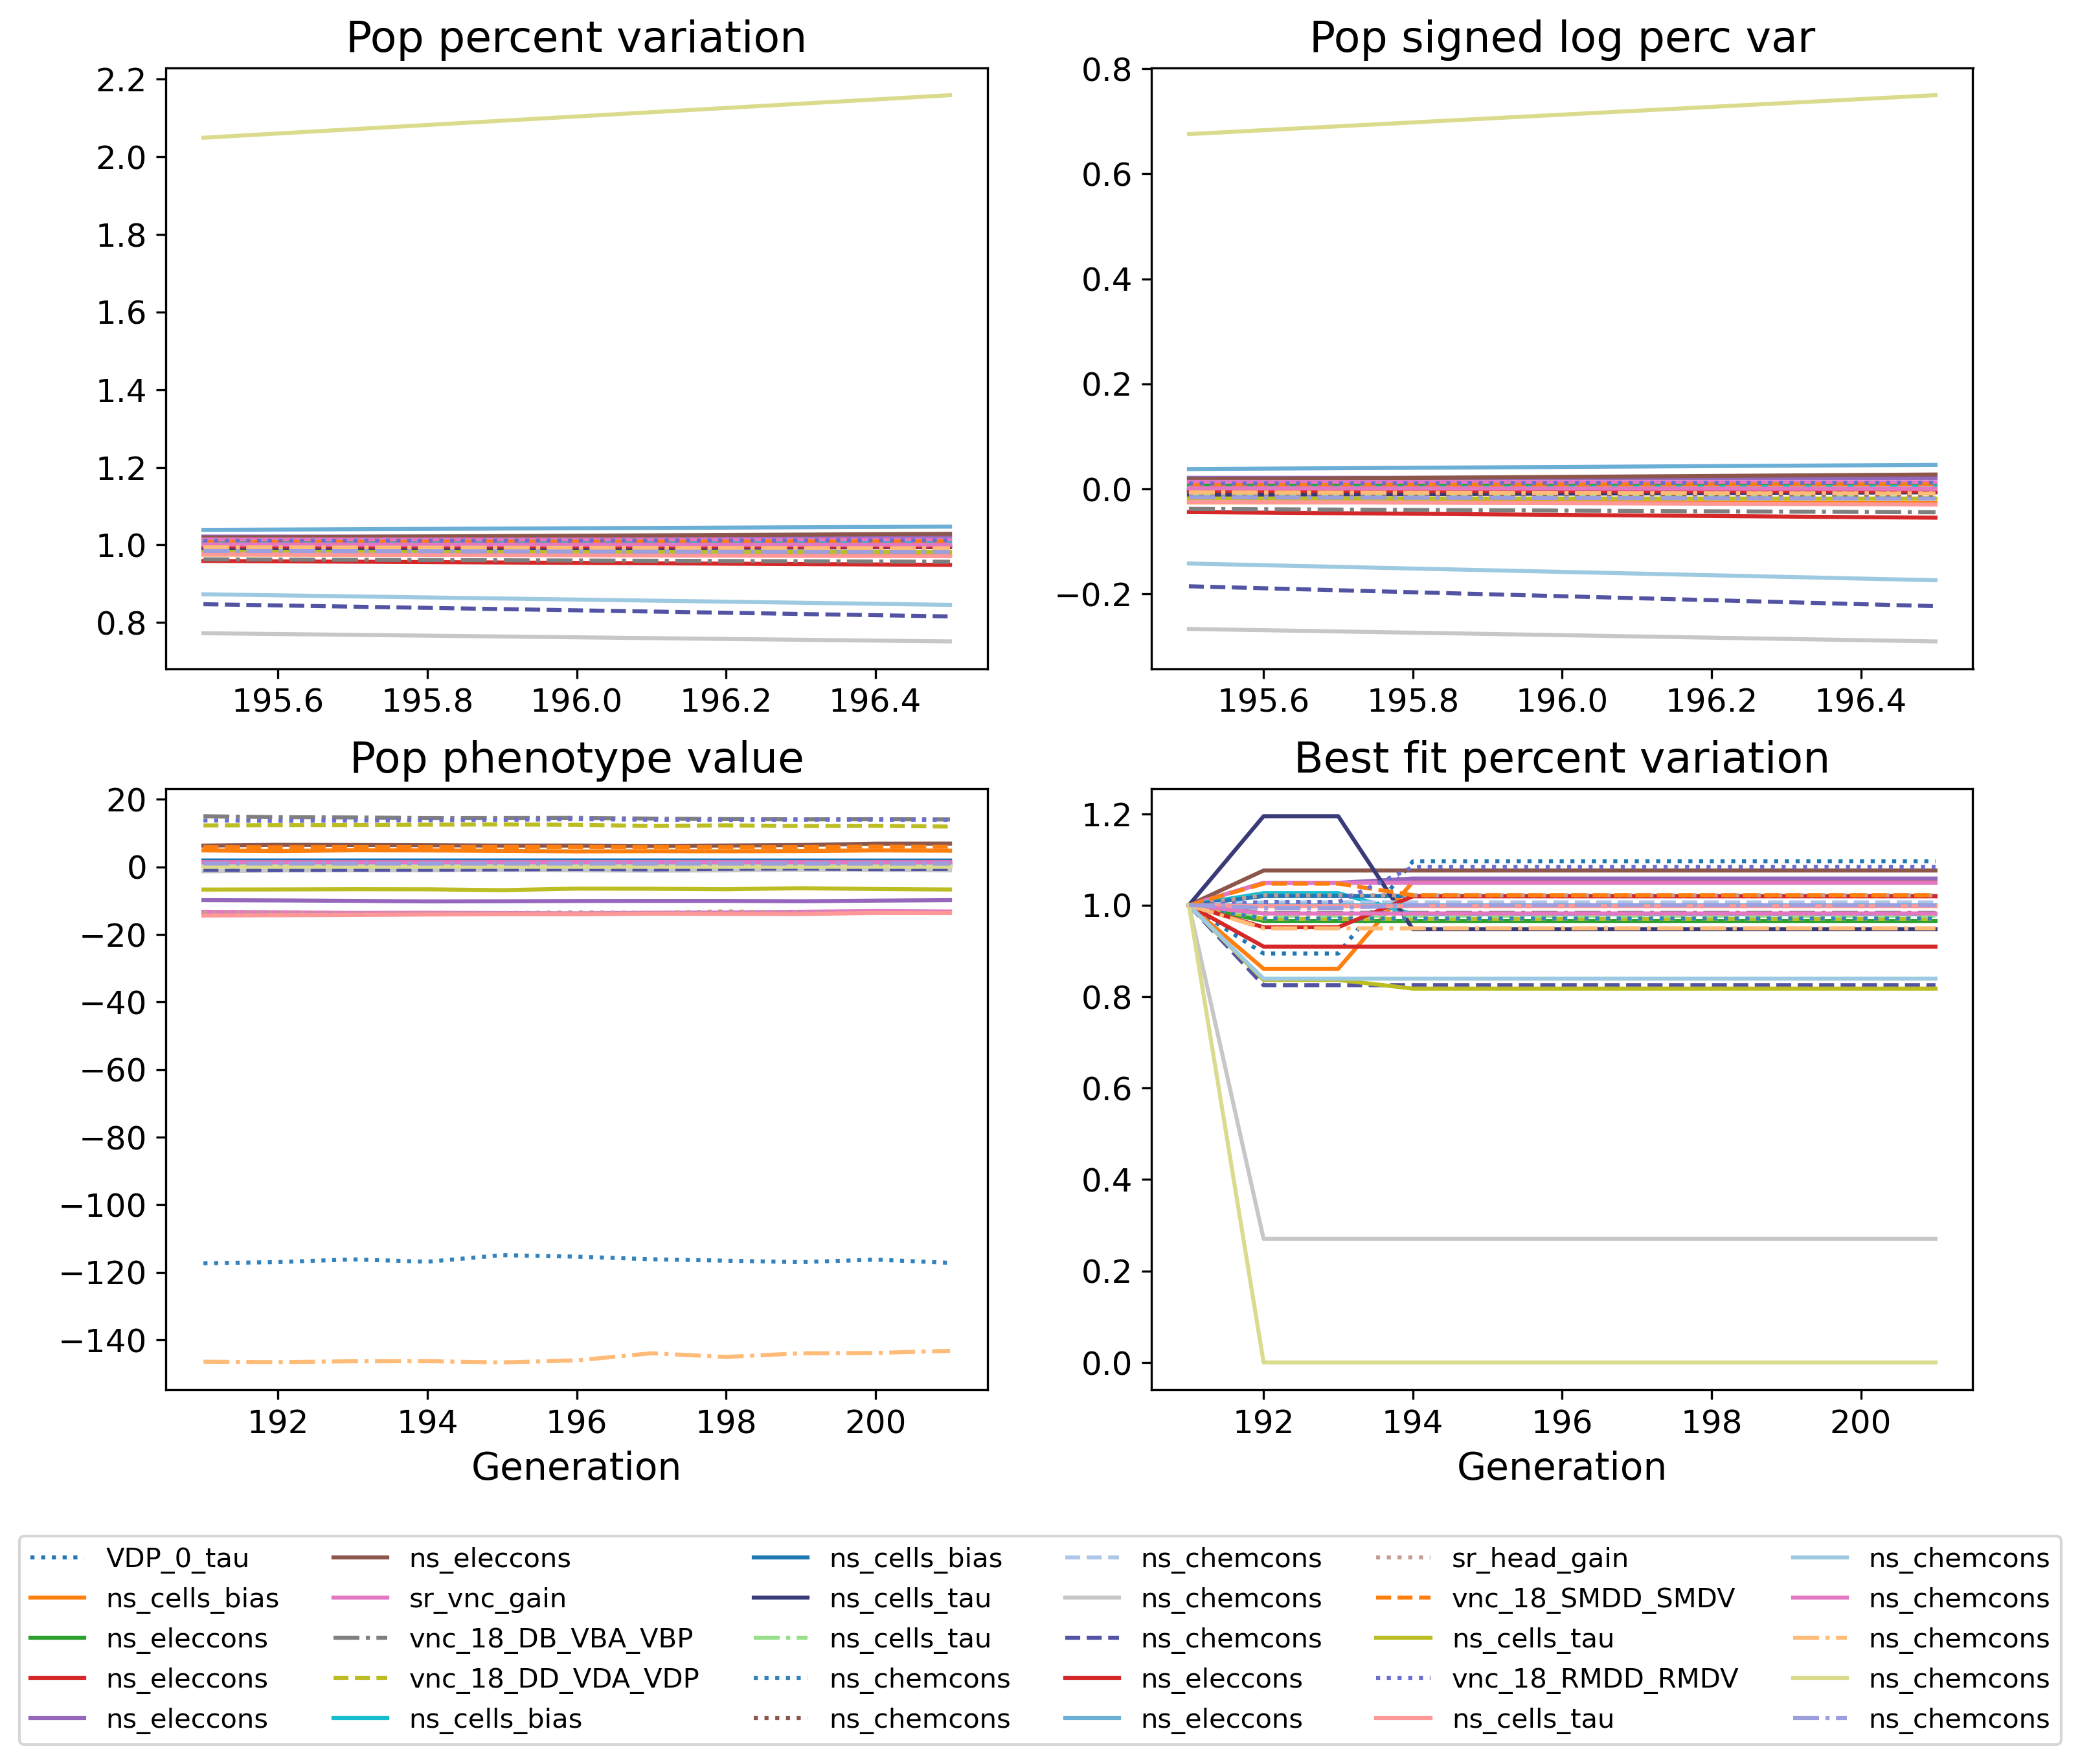

In [57]:
outputFolderName_3=origFolderName + "_evo_3"
write_worm_json(outputFolderName_3, new_json_data)
args['inputFolderName']= outputFolderName_2
args['outputFolderName']= outputFolderName_3
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=10 #run the optimization for ten more generations 
args['doCPT']=True
run(**args)
new_json_data = get_worm_json(outputFolderName_3)
Image(filename=outputFolderName_3 + '/EvoHist.png')

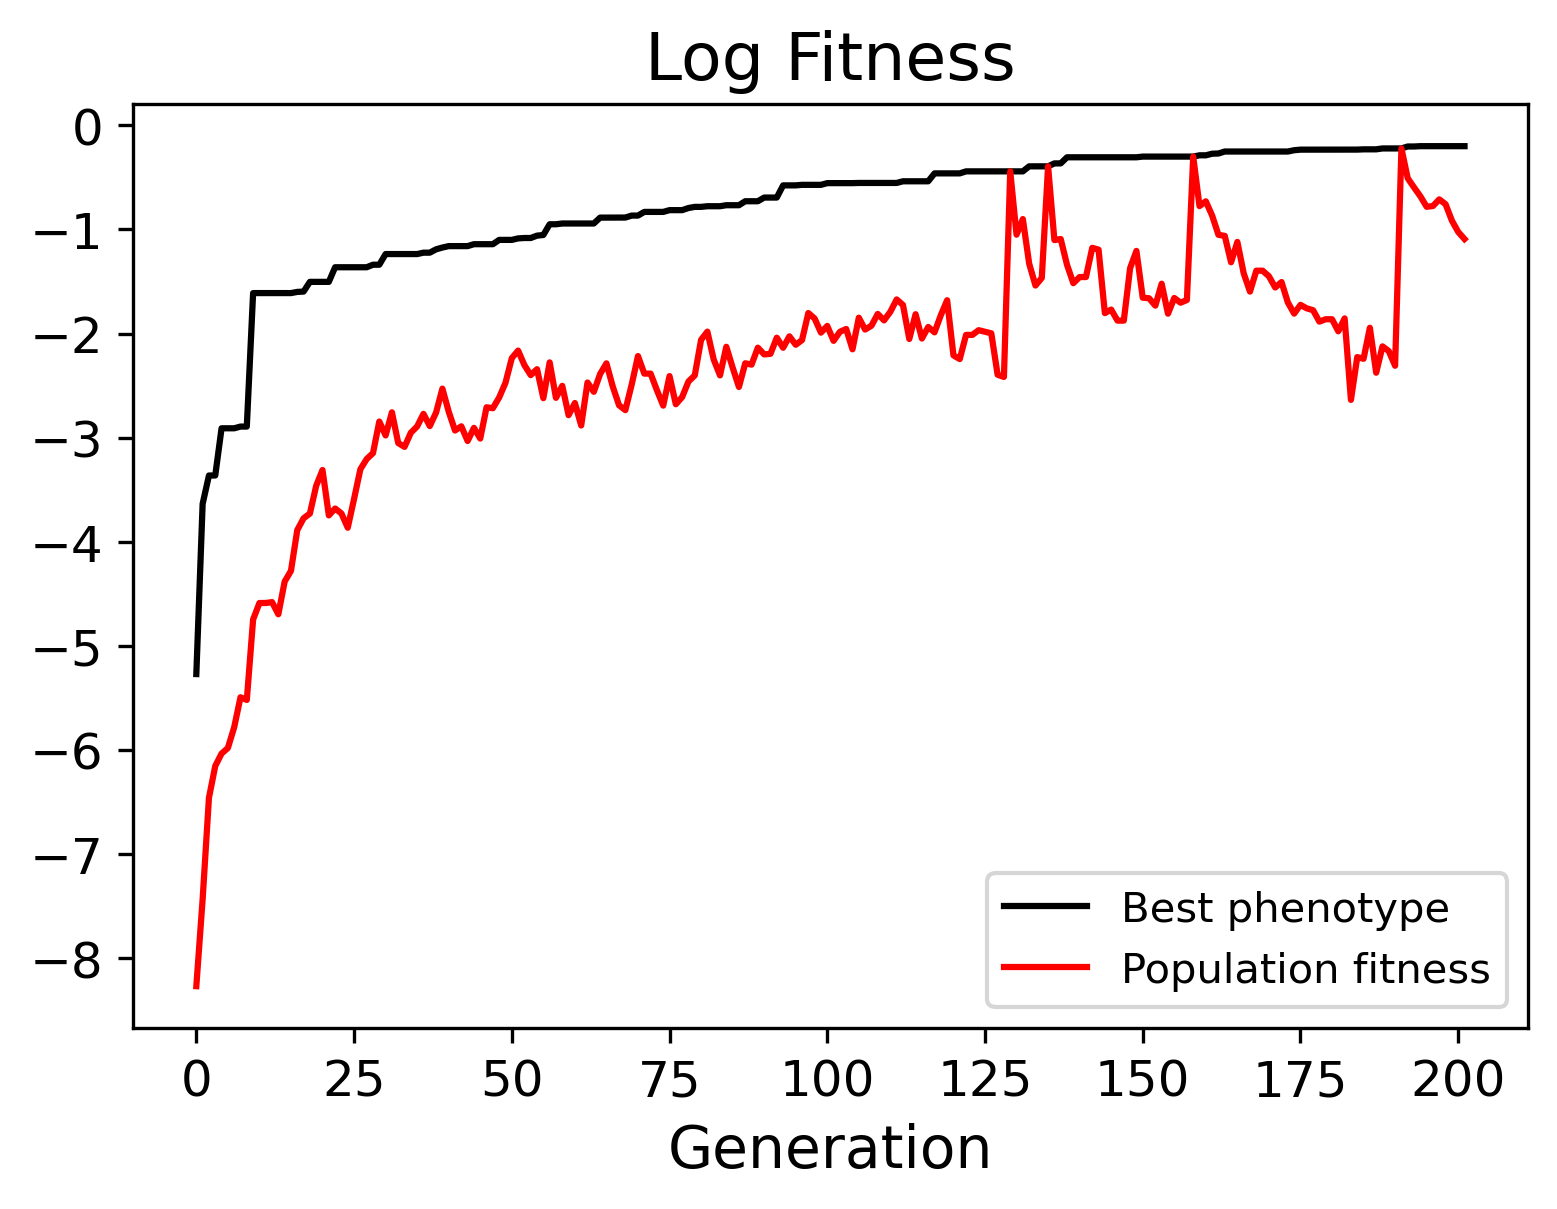

In [58]:
Image(filename=outputFolderName_3 + '/EvoHist_fitness.png')

In [59]:
print('VDP_0: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_0'], indent=2))
print('VDP_1: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_1'], indent=2))

VDP_0: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.1527777777777778
  },
  "tau": {
    "evotag": "VDP_0_tau",
    "value": 1.6111582196012417
  }
}
VDP_1: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.282245615372705
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.3194444444444444
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 1.3369826443939594
  }
}


Directory 'notebooks/example_W2D18L_evo_3' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '40', '--max_generations', '10', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo_3', '--modelname', 'W2DSR', '-docpt', '1']
jsonfile notebooks/example_W2D18L_evo_3/worm_data_worm.json
jsonfile notebooks/example_W2D18L_evo_3/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_evo_3/search.cpt with size 30
Resuming search
jsonfile notebooks/example_W2D18L_evo_3/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo_3/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo_3/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo_3/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo_3/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo_3/body.dat
Saved plot image to: notebooks/examp

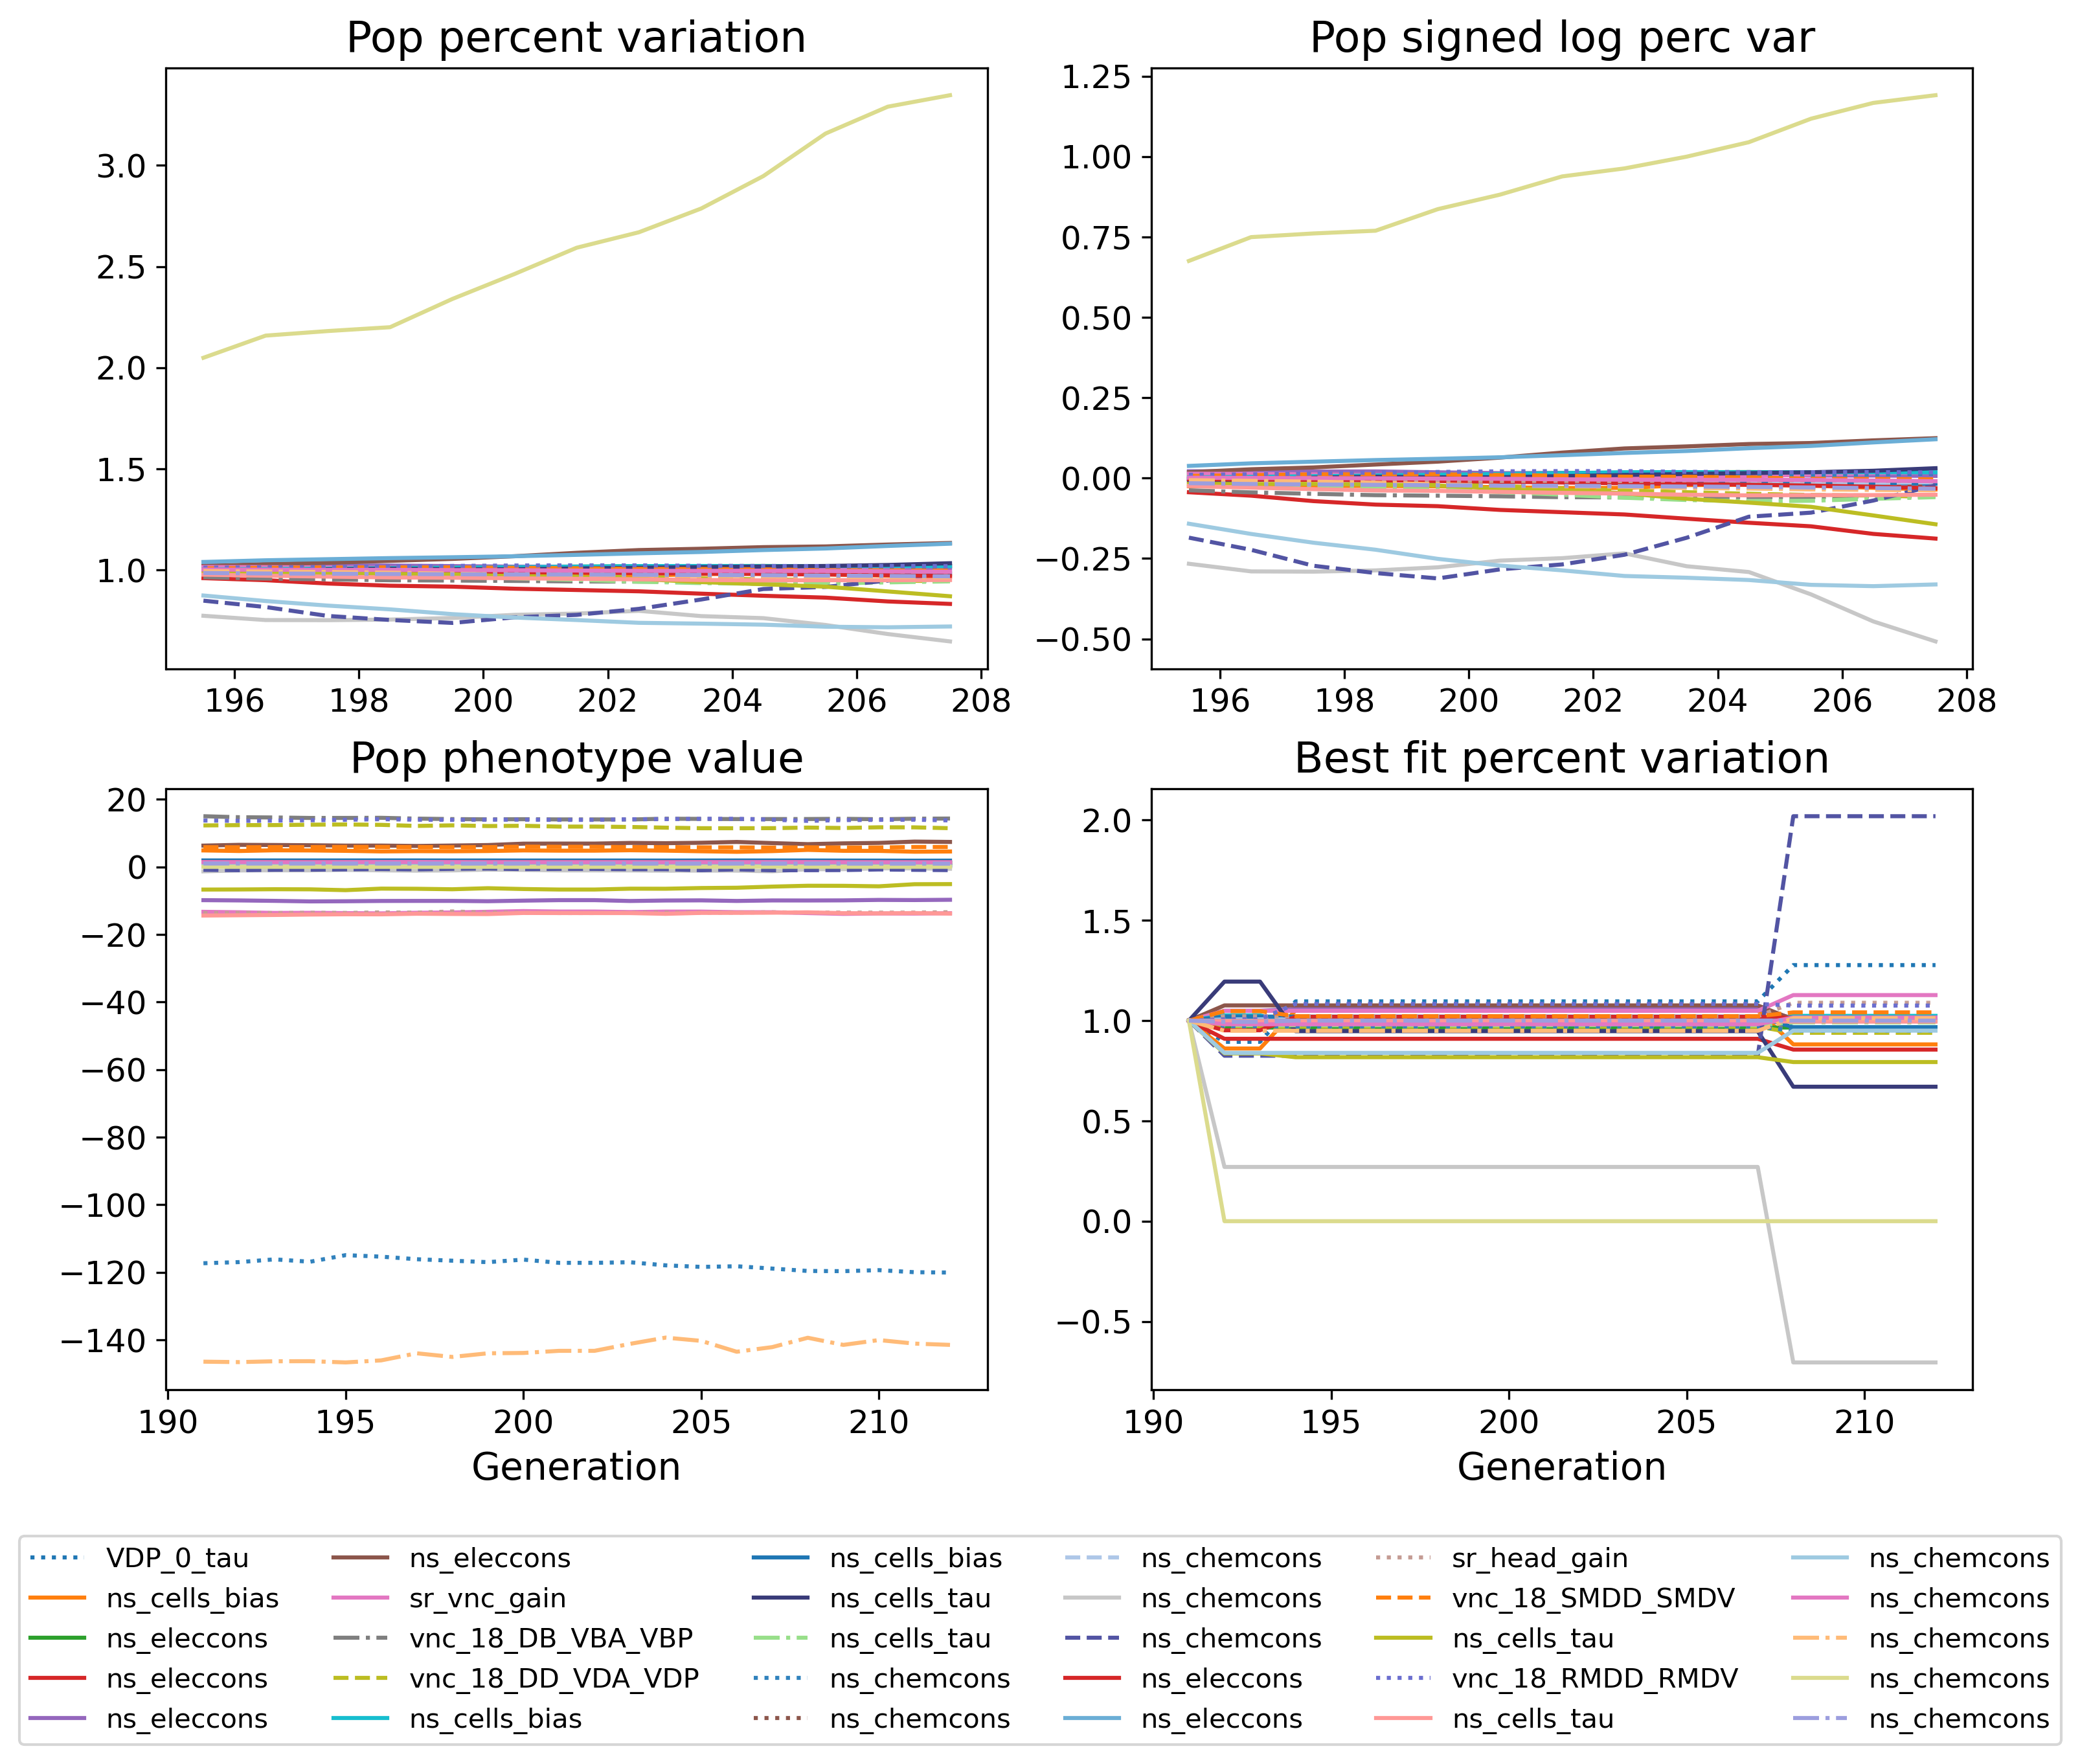

In [60]:
args['inputFolderName']= None
args['maxGens']=10 #run the optimization for ten more generations 
args['doCPT']=True
run(**args)
new_json_data = get_worm_json(outputFolderName_3)
Image(filename=outputFolderName_3 + '/EvoHist.png')

Some parameters may have an 'mfunc' field. This is a function which can be called on a value when it is set by the optimization or at other time (see below). 